In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

## Loading data

#### Mission data (for metrics for EQ2, EQ3, EQ4)

In [2]:

mission_data_df = pd.read_csv("../output/multi-mission/online-income/mission_data.csv")
mission_data_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,makespan,robot_id,robot_idle_time
0,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_1,410.642433
1,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_2,619.125929
2,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_3,992.985163
3,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_4,976.456206
4,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_5,983.995521
...,...,...,...,...,...,...,...,...,...
607,test-multi_2_10_t_cleaning_i2_bl1,2,10,2,cleaning,bl1,475.506605,robot_2,283.424830
608,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,117.010583,robot_1,29.997663
609,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,117.010583,robot_2,68.997043
610,test-multi_2_20_t_cleaning_i1_multi3,2,20,1,cleaning,multi3,576.021816,robot_1,6.018667


#### Execution data (for metrics for EQ1)

In [3]:
with open("../output/multi-mission/online-income/execution_check_results.json", 'r') as f:
    execution_data = json.load(f)

rows = []
for test_name, details in execution_data["mission_details"].items():
    labels = test_name.split("_")
    robot_count = int(labels[1])
    mission_size = int(labels[2])
    inv_id = int(labels[5][1])
    scenario = labels[4]
    mode = labels[6]
    row = {
        "test_id": test_name,
        "robot_count": robot_count,
        "mission_size": mission_size,
        "inventory_id": inv_id,
        "scenario": scenario,
        "mode": mode,
        "constrained_tasks": details["this_test_checks"],
        "respected_constraints": details["checks_passed"],
        "failed_constraints": details["checks_failed"],
        "test_result": details["test_ok"]
    }
    rows.append(row)

execution_data_df = pd.DataFrame(rows)
execution_data_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,constrained_tasks,respected_constraints,failed_constraints,test_result
0,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,40,40,0,True
1,test-multi_10_20_t_cleaning_i0_multi3,10,20,0,cleaning,multi3,33,33,0,True
2,test-multi_10_10_t_cleaning_i0_bl1,10,10,0,cleaning,bl1,20,20,0,True
3,test-multi_5_10_t_cleaning_i1_bl2,5,10,1,cleaning,bl2,20,20,0,True
4,test-multi_10_20_t_cleaning_i1_bl1,10,20,1,cleaning,bl1,40,40,0,True
...,...,...,...,...,...,...,...,...,...,...
103,test-multi_10_2_t_cleaning_i0_bl1,10,2,0,cleaning,bl1,4,4,0,True
104,test-multi_10_2_t_cleaning_i0_bl0,10,2,0,cleaning,bl0,4,4,0,True
105,test-multi_2_10_t_cleaning_i2_bl1,2,10,2,cleaning,bl1,20,20,0,True
106,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,4,4,0,True


## EQ1: Task order compliance

#### Metrics

Order satisfaction ratio:

$TOCR = \frac{1}{|\mathcal{O}|}\sum_{(t_i,t_j)\in\mathcal{O}} %\mathbf{1}_{end(t_i)\leq start(t_j)},
    \begin{cases}
    1 & \text{if  } end(t_i)\leq start(t_j) \\
    0 & \text{otherwise}
    \end{cases}
$

In [4]:
execution_data_df["tocr"] = execution_data_df["respected_constraints"] / execution_data_df["constrained_tasks"]
execution_data_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,constrained_tasks,respected_constraints,failed_constraints,test_result,tocr
0,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,40,40,0,True,1.0
1,test-multi_10_20_t_cleaning_i0_multi3,10,20,0,cleaning,multi3,33,33,0,True,1.0
2,test-multi_10_10_t_cleaning_i0_bl1,10,10,0,cleaning,bl1,20,20,0,True,1.0
3,test-multi_5_10_t_cleaning_i1_bl2,5,10,1,cleaning,bl2,20,20,0,True,1.0
4,test-multi_10_20_t_cleaning_i1_bl1,10,20,1,cleaning,bl1,40,40,0,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...
103,test-multi_10_2_t_cleaning_i0_bl1,10,2,0,cleaning,bl1,4,4,0,True,1.0
104,test-multi_10_2_t_cleaning_i0_bl0,10,2,0,cleaning,bl0,4,4,0,True,1.0
105,test-multi_2_10_t_cleaning_i2_bl1,2,10,2,cleaning,bl1,20,20,0,True,1.0
106,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,4,4,0,True,1.0


In [5]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_baseline = execution_data_df[execution_data_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_baseline_avg = (
    df_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "constrained_tasks": "mean",
        "respected_constraints": "mean",
        "failed_constraints": "mean",
        "tocr": "mean"
    })
)

df_baseline_avg["mode"] = "baseline"

df_multi3 = execution_data_df[execution_data_df["mode"] == "multi3"].copy()

df_grouped = pd.concat([df_baseline_avg, df_multi3], ignore_index=True)

df_grouped = df_grouped[group_cols + ["mode", "constrained_tasks", "respected_constraints", "failed_constraints", "tocr"]]
df_grouped

,scenario,robot_count,mission_size,inventory_id,mode,constrained_tasks,respected_constraints,failed_constraints,tocr
0,cleaning,2,2,0,baseline,4.000000,4.000000,0.0,1.0
1,cleaning,2,2,1,baseline,4.000000,4.000000,0.0,1.0
2,cleaning,2,2,2,baseline,4.000000,4.000000,0.0,1.0
3,cleaning,2,10,0,baseline,20.000000,20.000000,0.0,1.0
4,cleaning,2,10,1,baseline,20.000000,20.000000,0.0,1.0
5,cleaning,2,10,2,baseline,20.000000,20.000000,0.0,1.0
6,cleaning,2,20,0,baseline,39.000000,39.000000,0.0,1.0
7,cleaning,2,20,1,baseline,38.000000,38.000000,0.0,1.0
8,cleaning,2,20,2,baseline,39.333333,39.333333,0.0,1.0
9,cleaning,5,2,0,baseline,4.000000,4.000000,0.0,1.0


In [6]:
pivot_df = df_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["constrained_tasks", "respected_constraints", "failed_constraints", "tocr"]
)

pivot_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_df.columns]

pivot_df = pivot_df.reset_index()
pivot_df

,scenario,robot_count,mission_size,inventory_id,constrained_tasks_baseline,constrained_tasks_multi3,failed_constraints_baseline,failed_constraints_multi3,respected_constraints_baseline,respected_constraints_multi3,tocr_baseline,tocr_multi3
0,cleaning,2,2,0,4.000000,4.0,0.0,0.0,4.000000,4.0,1.0,1.0
1,cleaning,2,2,1,4.000000,4.0,0.0,0.0,4.000000,4.0,1.0,1.0
2,cleaning,2,2,2,4.000000,4.0,0.0,0.0,4.000000,4.0,1.0,1.0
3,cleaning,2,10,0,20.000000,20.0,0.0,0.0,20.000000,20.0,1.0,1.0
4,cleaning,2,10,1,20.000000,20.0,0.0,0.0,20.000000,20.0,1.0,1.0
5,cleaning,2,10,2,20.000000,20.0,0.0,0.0,20.000000,20.0,1.0,1.0
6,cleaning,2,20,0,39.000000,40.0,0.0,0.0,39.000000,40.0,1.0,1.0
7,cleaning,2,20,1,38.000000,40.0,0.0,0.0,38.000000,40.0,1.0,1.0
8,cleaning,2,20,2,39.333333,40.0,0.0,0.0,39.333333,40.0,1.0,1.0
9,cleaning,5,2,0,4.000000,4.0,0.0,0.0,4.000000,4.0,1.0,1.0


In [7]:
df_avg = (
    pivot_df
    .groupby("scenario", as_index=False)
    .agg({
        "tocr_baseline": "mean",
        "tocr_multi3": "mean",
    })
)

df_avg["tocr_diff_percentage"] = ((df_avg["tocr_multi3"] - df_avg["tocr_baseline"]) / df_avg["tocr_baseline"]) *100

df_avg

,scenario,tocr_baseline,tocr_multi3,tocr_diff_percentage
0,cleaning,1.0,1.0,0.0


## EQ2: Mission completion time analysis

#### Data report

In [8]:
df_mission = (
    mission_data_df.groupby("test_id")
      .agg({
          "robot_count": "first",
          "mission_size": "first",
          "inventory_id": "first",
          "scenario": "first",
          "mode": "first",
          "makespan": "first",
          "robot_idle_time": "mean"
      })
      .reset_index()
)

df_mission.rename(columns={"robot_idle_time": "average_robot_idle_time"}, inplace=True)
df_mission = df_mission[["scenario", "robot_count", "mission_size", "inventory_id", "mode", "makespan", "average_robot_idle_time"]]

df_mission

,scenario,robot_count,mission_size,inventory_id,mode,makespan,average_robot_idle_time
0,cleaning,10,10,0,bl0,487.505440,435.087561
1,cleaning,10,10,0,bl1,489.047070,436.465769
2,cleaning,10,10,0,bl2,490.507778,438.382280
3,cleaning,10,10,0,multi3,96.047190,44.650114
4,cleaning,10,10,1,bl0,456.040201,406.459286
...,...,...,...,...,...,...,...
103,cleaning,5,2,1,multi3,70.535134,45.651161
104,cleaning,5,2,2,bl0,94.502743,71.393866
105,cleaning,5,2,2,bl1,90.032507,67.541684
106,cleaning,5,2,2,bl2,91.505299,68.699151


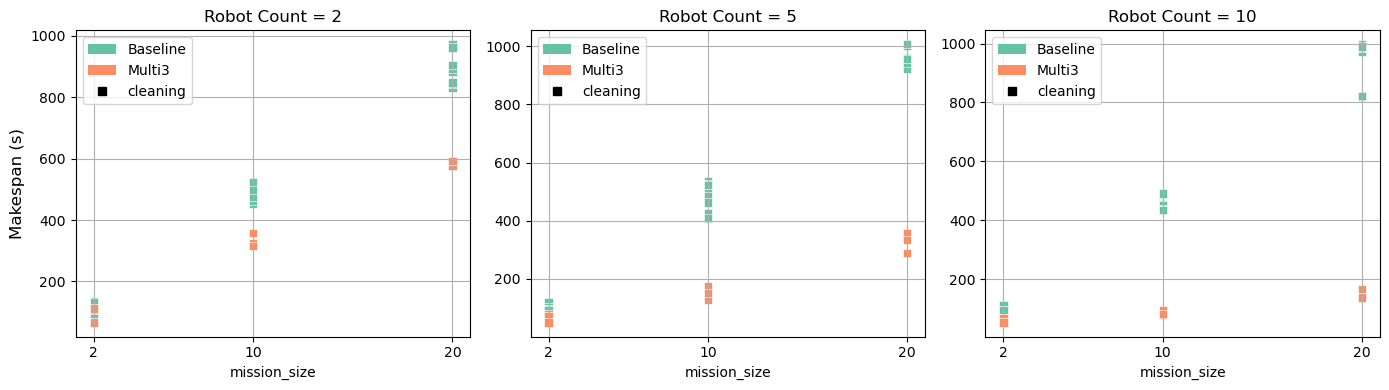

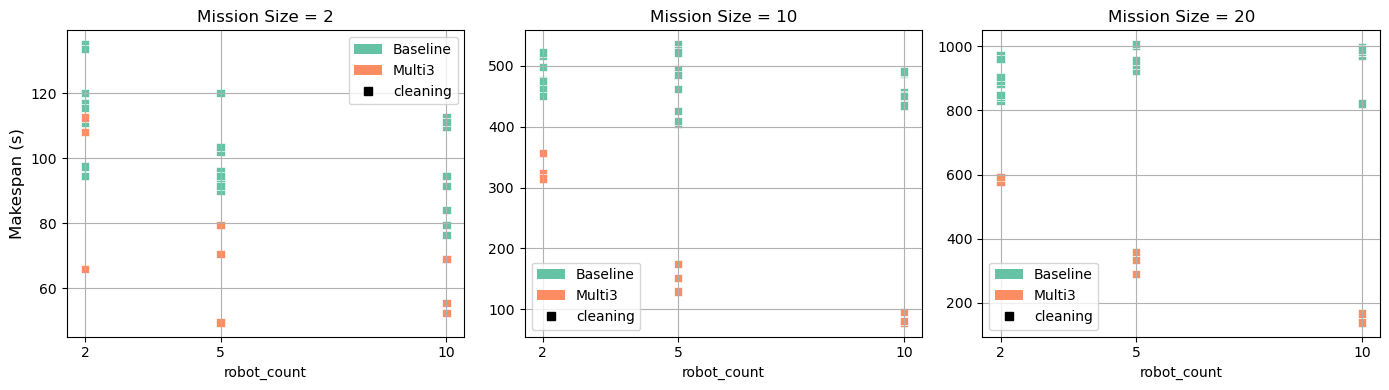

In [9]:
def multiplot(df,fname,external_variable,var_x,var_y,title,x_label,y_label):
    marker_dict = {
        'agriculture': 'o',
        'cleaning': 's',
        'logistics': '^',
        'surveillance': 'D',
        'other': 'v'
    }
    palette = sns.color_palette("Set2")
    approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for i, v in enumerate(external_variable_values):
        x_df = df[(df[external_variable] == v)][[var_x,var_y,"mode","scenario"]]
        bl_df = x_df[(x_df["mode"] == "bl0") | (x_df["mode"] == "bl1") | (x_df["mode"] == "bl2")]

        m3_df = x_df[x_df["mode"] == "multi3"]

        sns.scatterplot(data=bl_df, x=var_x, y=var_y, style='scenario', color=approach_colors['Baseline'], ax=axes[i], markers=marker_dict)
        sns.scatterplot(data=m3_df, x=var_x, y=var_y, style='scenario', color=approach_colors['Multi3'], ax=axes[i], markers=marker_dict)

        axes[i].set_title(title.replace("$field$",str(v)))
        if i == 0:
            axes[i].set_ylabel(y_label, fontsize=12)
        else:
            axes[i].set_ylabel("")
        axes[i].set_xticks(sorted(x_df[var_x].unique()))
        
        color_handles = [
            Patch(facecolor=approach_colors['Baseline'], label='Baseline'),
            Patch(facecolor=approach_colors['Multi3'], label='Multi3')
        ]

        marker_handles = [
            Line2D([0], [0], marker=marker_dict[s], color='black', linestyle='None', label=s) for s in df["scenario"].unique() 
        ]

        axes[i].legend(handles=color_handles + marker_handles)
        axes[i].grid()

    plt.tight_layout()
    plt.savefig(fname, format="pdf")
    plt.show()

multiplot(df_mission, "../output/multi-mission/online-income/images/ms_by_mission_size_scatter.pdf", "robot_count", "mission_size","makespan","Robot Count = $field$", "Mission Size", "Makespan (s)")
multiplot(df_mission, "../output/multi-mission/online-income/images/ms_by_robot_count_scatter.pdf", "mission_size", "robot_count","makespan","Mission Size = $field$", "Robot Count", "Makespan (s)")

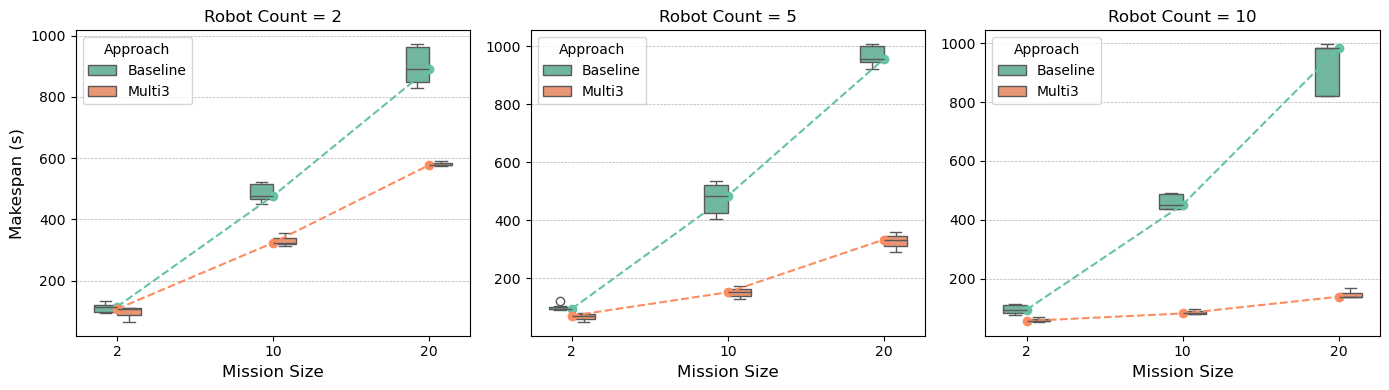

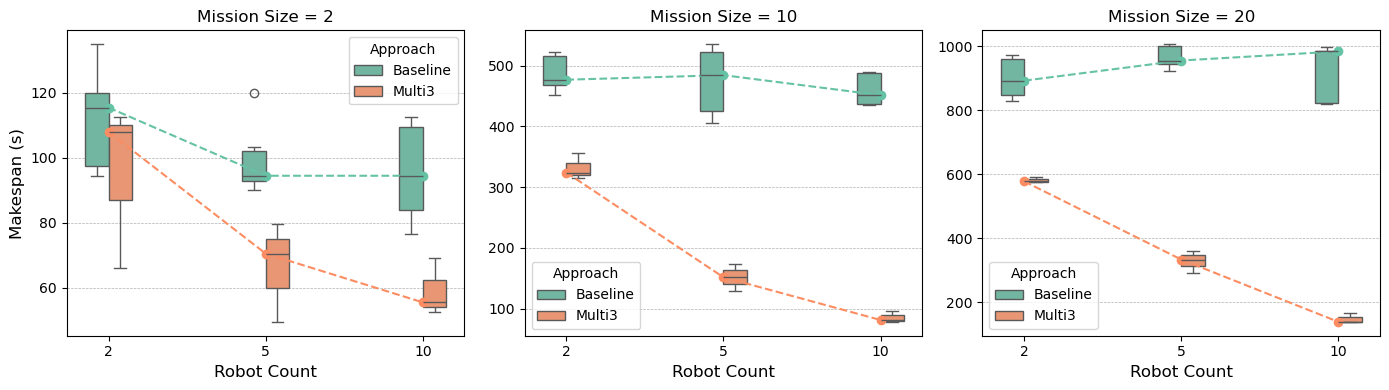

In [10]:
palette = sns.color_palette("Set2")
approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

def multi_box_plot(df,output_file_name, external_variable, var_x, var_y, external_variable_label, x_label, y_label):
    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(14, 4))

    for i, external_variable_value in enumerate(external_variable_values):
        ax = axes[i]
        xx_df = df[df[external_variable] == external_variable_value][[var_x, var_y, "mode"]].copy()
        xx_df["Approach"] = xx_df["mode"].apply(lambda x: "Baseline" if x in {"bl0", "bl1", "bl2"} else "Multi3")

        sns.boxplot(data=xx_df, x=var_x, y=var_y, hue="Approach", palette=approach_colors, width=0.3, ax=ax)

        mission_sizes = sorted(xx_df[var_x].unique())
        x_ticks = range(len(mission_sizes))

        for approach, color in approach_colors.items():
            medians = []
            for size in mission_sizes:
                values = xx_df[(xx_df[var_x] == size) & (xx_df["Approach"] == approach)][var_y]
                if not values.empty:
                    medians.append(np.median(values))
                else:
                    medians.append(np.nan)

            ax.plot(x_ticks, medians, marker="o", linestyle="--", color=color)

        ax.set_title(f"{external_variable_label} = {external_variable_value}")
        ax.set_xlabel(x_label, fontsize=12)
        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")
        ax.yaxis.grid(True, linestyle="--", linewidth=0.5)

    plt.tight_layout()
    plt.savefig(output_file_name, format="pdf")
    plt.show()

multi_box_plot(df_mission, "../output/multi-mission/online-income/images/ms_by_mission_size_box.pdf", "robot_count", "mission_size", "makespan", "Robot Count", "Mission Size", "Makespan (s)")
multi_box_plot(df_mission, "../output/multi-mission/online-income/images/ms_by_robot_count_box.pdf", "mission_size", "robot_count", "makespan", "Mission Size", "Robot Count", "Makespan (s)")

#### Data analysis

Grouping baseline execution and compute average

In [11]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_baseline = df_mission[df_mission["mode"].isin(["bl0", "bl1", "bl2"])]

df_baseline_avg = (
    df_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "makespan": "mean",
        "average_robot_idle_time": "mean"
    })
)

df_baseline_avg["mode"] = "baseline"

df_multi3 = df_mission[df_mission["mode"] == "multi3"].copy()

df_grouped = pd.concat([df_baseline_avg, df_multi3], ignore_index=True)

df_grouped = df_grouped[group_cols + ["mode", "makespan", "average_robot_idle_time"]]
df_grouped

,scenario,robot_count,mission_size,inventory_id,mode,makespan,average_robot_idle_time
0,cleaning,2,2,0,baseline,117.532520,51.015221
1,cleaning,2,2,1,baseline,126.512255,59.262286
2,cleaning,2,2,2,baseline,95.507971,41.500075
3,cleaning,2,10,0,baseline,461.006987,219.987351
4,cleaning,2,10,1,baseline,518.014288,243.652535
5,cleaning,2,10,2,baseline,483.512134,229.421592
6,cleaning,2,20,0,baseline,965.009648,465.319522
7,cleaning,2,20,1,baseline,840.013026,409.989350
8,cleaning,2,20,2,baseline,893.507780,435.994814
9,cleaning,5,2,0,baseline,108.520076,81.329691


Linearizing experiment modes (baseline vs multi3)

In [12]:
pivot_df = df_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["makespan", "average_robot_idle_time"]
)

pivot_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_df.columns]

pivot_df = pivot_df.reset_index()

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "makespan_baseline",
    "makespan_multi3",
    "average_robot_idle_time_baseline",
    "average_robot_idle_time_multi3",
]
pivot_df = pivot_df[ordered_cols]

pivot_df

,scenario,robot_count,mission_size,inventory_id,makespan_baseline,makespan_multi3,average_robot_idle_time_baseline,average_robot_idle_time_multi3
0,cleaning,2,2,0,117.532520,108.019715,51.015221,35.264056
1,cleaning,2,2,1,126.512255,112.508743,59.262286,32.254863
2,cleaning,2,2,2,95.507971,66.019072,41.500075,9.762645
3,cleaning,2,10,0,461.006987,324.021297,219.987351,15.770951
4,cleaning,2,10,1,518.014288,357.010663,243.652535,36.009722
5,cleaning,2,10,2,483.512134,315.020325,229.421592,22.523124
6,cleaning,2,20,0,965.009648,577.510306,465.319522,14.263976
7,cleaning,2,20,1,840.013026,576.021816,409.989350,4.521195
8,cleaning,2,20,2,893.507780,592.506083,435.994814,8.264548
9,cleaning,5,2,0,108.520076,79.505620,81.329691,50.123052


#### Computing differences per experiment configuration

In [13]:
makespans_df = pivot_df[["scenario", "robot_count", "mission_size", "inventory_id", "makespan_baseline", "makespan_multi3"]].copy()

makespans_df["makespan_diff_percentage"] = ((makespans_df["makespan_multi3"] - makespans_df["makespan_baseline"]) / makespans_df["makespan_baseline"]) * 100
makespans_df["makespan_paired_diff"] = makespans_df["makespan_baseline"] - makespans_df["makespan_multi3"]

makespans_df

,scenario,robot_count,mission_size,inventory_id,makespan_baseline,makespan_multi3,makespan_diff_percentage,makespan_paired_diff
0,cleaning,2,2,0,117.532520,108.019715,-8.093764,9.512805
1,cleaning,2,2,1,126.512255,112.508743,-11.068898,14.003512
2,cleaning,2,2,2,95.507971,66.019072,-30.875851,29.488899
3,cleaning,2,10,0,461.006987,324.021297,-29.714450,136.985689
4,cleaning,2,10,1,518.014288,357.010663,-31.080924,161.003625
5,cleaning,2,10,2,483.512134,315.020325,-34.847483,168.491809
6,cleaning,2,20,0,965.009648,577.510306,-40.154971,387.499342
7,cleaning,2,20,1,840.013026,576.021816,-31.427038,263.991210
8,cleaning,2,20,2,893.507780,592.506083,-33.687641,301.001696
9,cleaning,5,2,0,108.520076,79.505620,-26.736487,29.014456


### Analyzing percentage differences

In [14]:
makespans_stats = (
    makespans_df.groupby(["mission_size", "robot_count"])
    .agg({
        "makespan_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

makespans_stats.columns = ["mission_size", "robot_count", "min_makespan_diff_percentage", "max_makespan_diff_percentage", "mean_makespan_diff_percentage", "median_makespan_diff_percentage"]

makespans_stats

,mission_size,robot_count,min_makespan_diff_percentage,max_makespan_diff_percentage,mean_makespan_diff_percentage,median_makespan_diff_percentage
0,2,2,-30.875851,-8.093764,-16.679504,-11.068898
1,2,5,-46.195725,-24.985011,-32.639074,-26.736487
2,2,10,-43.846478,-30.635997,-37.428918,-37.804277
3,10,2,-34.847483,-29.714450,-31.880952,-31.080924
4,10,5,-71.306266,-63.785713,-67.962911,-68.796755
5,10,10,-82.753124,-80.359255,-81.501128,-81.391006
6,20,2,-40.154971,-31.427038,-35.089883,-33.687641
7,20,5,-68.970556,-64.292860,-66.093549,-65.017232
8,20,10,-86.062268,-79.732283,-83.900455,-85.906813


In [15]:
makespans_stats = (
    makespans_df.groupby(["mission_size"])
    .agg({
        "makespan_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

makespans_stats.columns = ["mission_size", "min_makespan_diff_percentage", "max_makespan_diff_percentage", "mean_makespan_diff_percentage", "median_makespan_diff_percentage"]

makespans_stats

,mission_size,min_makespan_diff_percentage,max_makespan_diff_percentage,mean_makespan_diff_percentage,median_makespan_diff_percentage
0,2,-46.195725,-8.093764,-28.915832,-30.635997
1,10,-82.753124,-29.714450,-60.448331,-68.796755
2,20,-86.062268,-31.427038,-61.694629,-65.017232


In [16]:
makespans_stats = (
    makespans_df.groupby(["robot_count"])
    .agg({
        "makespan_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

makespans_stats.columns = ["robot_count", "min_makespan_diff_percentage", "max_makespan_diff_percentage", "mean_makespan_diff_percentage", "median_makespan_diff_percentage"]

makespans_stats

,robot_count,min_makespan_diff_percentage,max_makespan_diff_percentage,mean_makespan_diff_percentage,median_makespan_diff_percentage
0,2,-40.154971,-8.093764,-27.883447,-31.080924
1,5,-71.306266,-24.985011,-55.565178,-64.292860
2,10,-86.062268,-30.635997,-67.610167,-80.359255


#### Computing average values per scenario

In [17]:
df_completion_average = (
    makespans_df.groupby("scenario")
      .agg({
          "makespan_baseline": "mean",
          "makespan_multi3": "mean",
          "makespan_paired_diff": "mean",
          "makespan_diff_percentage": "mean"
      })
      .reset_index()
)

df_completion_average.rename(columns={"makespan_diff_percentage": "average_of_makespan_diff_percentage"}, inplace=True)

df_completion_average["diff_percentage_on_average_times"] = (df_completion_average["makespan_multi3"] - df_completion_average["makespan_baseline"]) / df_completion_average["makespan_baseline"] * 100

df_completion_average

,scenario,makespan_baseline,makespan_multi3,makespan_paired_diff,average_of_makespan_diff_percentage,diff_percentage_on_average_times
0,cleaning,502.204534,205.133993,297.070541,-50.352931,-59.153297


#### Plotting average completion times per scenario

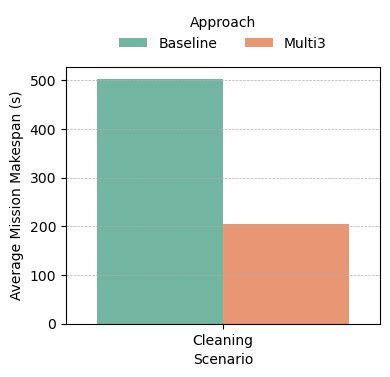

In [18]:
melted = df_completion_average.melt(id_vars='scenario', value_vars=['makespan_baseline', 'makespan_multi3'], var_name='mode', value_name='coefficient')

melted['mode'] = melted['mode'].replace({'makespan_baseline': 'Baseline', 'makespan_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='coefficient', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Average Mission Makespan (s)')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/multi-mission/online-income/images/ms_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Wilcoxon test on paired differences

In [19]:
## Wilcoxon signed-rank test for makespan differences (on paired samples, to check if the differences are statistically significant, we want to test if multi3 is significantly lower than baseline)
wilcoxon_test = wilcoxon(makespans_df['makespan_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on makespan:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test on makespan:
Statistic: 0.0, p-value: 1.4901161193847656e-08


In [20]:
# Checking only with mission_size = 2
wilcoxon_test_mission_size_2 = wilcoxon(makespans_df[makespans_df['mission_size'] == 2]['makespan_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on makespan(mission_size = 2):\nStatistic: {wilcoxon_test_mission_size_2.statistic}, p-value: {wilcoxon_test_mission_size_2.pvalue}")

Wilcoxon signed-rank test on makespan(mission_size = 2):
Statistic: 0.0, p-value: 0.00390625


In [21]:
median_mission_size = makespans_df['makespan_paired_diff'].median()
percentile_5_mission_size = makespans_df['makespan_paired_diff'].quantile(0.05)

print(f"Makespan paired difference median: {median_mission_size}")
print(f"5th percentile: {percentile_5_mission_size}")

Makespan paired difference median: 284.49237116177875
5th percentile: 16.85033458868663


In [22]:
median_mission_size = makespans_df[makespans_df['mission_size'] == 2]['makespan_paired_diff'].median()
percentile_5_mission_size = makespans_df[makespans_df['mission_size'] == 2]['makespan_paired_diff'].quantile(0.05)

print(f"Makespan paired difference median (mission size = 2): {median_mission_size}")
print(f"5th percentile (mission size = 2): {percentile_5_mission_size}")

Makespan paired difference median (mission size = 2): 29.014455795288086
5th percentile (mission size = 2): 11.309087912241612


## EQ3: Analyzing improvements in idle times

#### Computing idle time ratios per experiment configuration

Metric:

$IdleRatio = \frac{\sum_{r} IdleTime_{r}}{|R| \times CompletionTime}$

where $R$ is the set of robots involved in the mission

In [23]:
idle_times_df = pivot_df[["scenario", "robot_count", "mission_size", "inventory_id", "makespan_baseline", "makespan_multi3", "average_robot_idle_time_baseline", "average_robot_idle_time_multi3"]].copy()

idle_times_df["average_robot_idle_time_diff_percentage"] = (idle_times_df["average_robot_idle_time_multi3"] - idle_times_df["average_robot_idle_time_baseline"]) / idle_times_df["average_robot_idle_time_baseline"] * 100

idle_times_df["idle_ratio_baseline"] = idle_times_df["average_robot_idle_time_baseline"] / idle_times_df["makespan_baseline"]
idle_times_df["idle_ratio_multi3"] = idle_times_df["average_robot_idle_time_multi3"] / idle_times_df["makespan_multi3"]

idle_times_df["idle_ratio_diff_percentage"] = (idle_times_df["idle_ratio_multi3"] - idle_times_df["idle_ratio_baseline"]) / idle_times_df["idle_ratio_baseline"] * 100
idle_times_df["idle_ratio_paired_diff"] = idle_times_df["idle_ratio_baseline"] - idle_times_df["idle_ratio_multi3"]

idle_times_df

,scenario,robot_count,mission_size,inventory_id,makespan_baseline,makespan_multi3,average_robot_idle_time_baseline,average_robot_idle_time_multi3,average_robot_idle_time_diff_percentage,idle_ratio_baseline,idle_ratio_multi3,idle_ratio_diff_percentage,idle_ratio_paired_diff
0,cleaning,2,2,0,117.532520,108.019715,51.015221,35.264056,-30.875422,0.434052,0.326459,-24.787935,0.107593
1,cleaning,2,2,1,126.512255,112.508743,59.262286,32.254863,-45.572698,0.468431,0.286688,-38.798350,0.181744
2,cleaning,2,2,2,95.507971,66.019072,41.500075,9.762645,-76.475597,0.434519,0.147876,-65.967895,0.286643
3,cleaning,2,10,0,461.006987,324.021297,219.987351,15.770951,-92.830974,0.477189,0.048673,-89.800142,0.428516
4,cleaning,2,10,1,518.014288,357.010663,243.652535,36.009722,-85.220871,0.470359,0.100865,-78.555823,0.369494
5,cleaning,2,10,2,483.512134,315.020325,229.421592,22.523124,-90.182649,0.474490,0.071497,-84.931739,0.402992
6,cleaning,2,20,0,965.009648,577.510306,465.319522,14.263976,-96.934585,0.482192,0.024699,-94.877744,0.457492
7,cleaning,2,20,1,840.013026,576.021816,409.989350,4.521195,-98.897241,0.488075,0.007849,-98.391846,0.480226
8,cleaning,2,20,2,893.507780,592.506083,435.994814,8.264548,-98.104439,0.487959,0.013948,-97.141466,0.474010
9,cleaning,5,2,0,108.520076,79.505620,81.329691,50.123052,-38.370538,0.749444,0.630434,-15.879734,0.119010


#### Plotting idle ratios for each experimental run

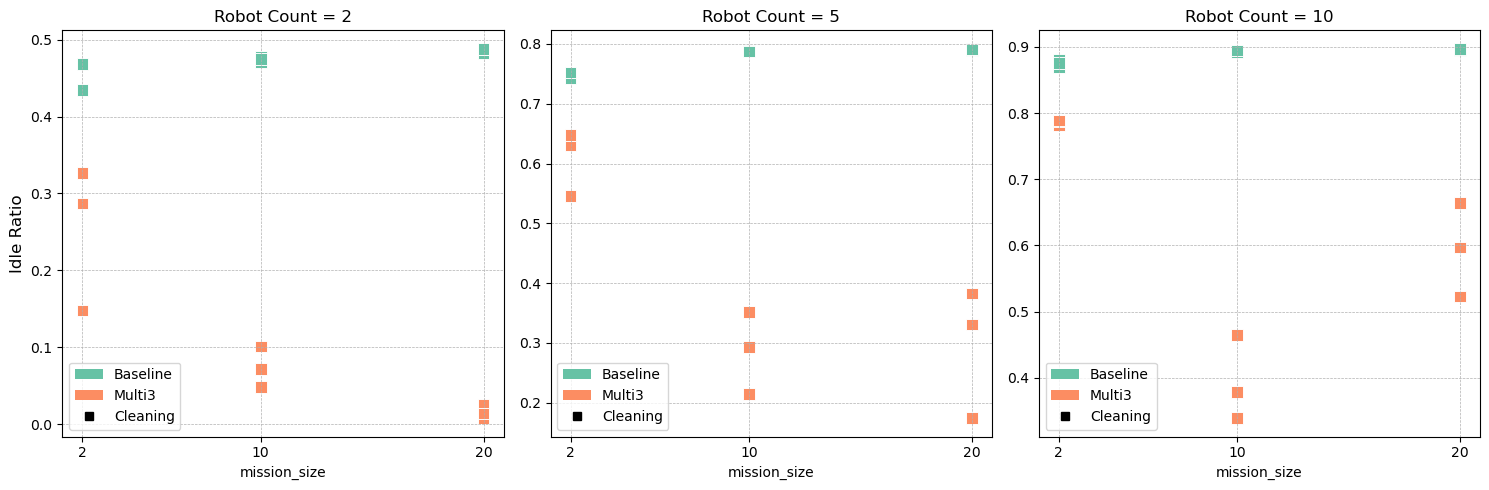

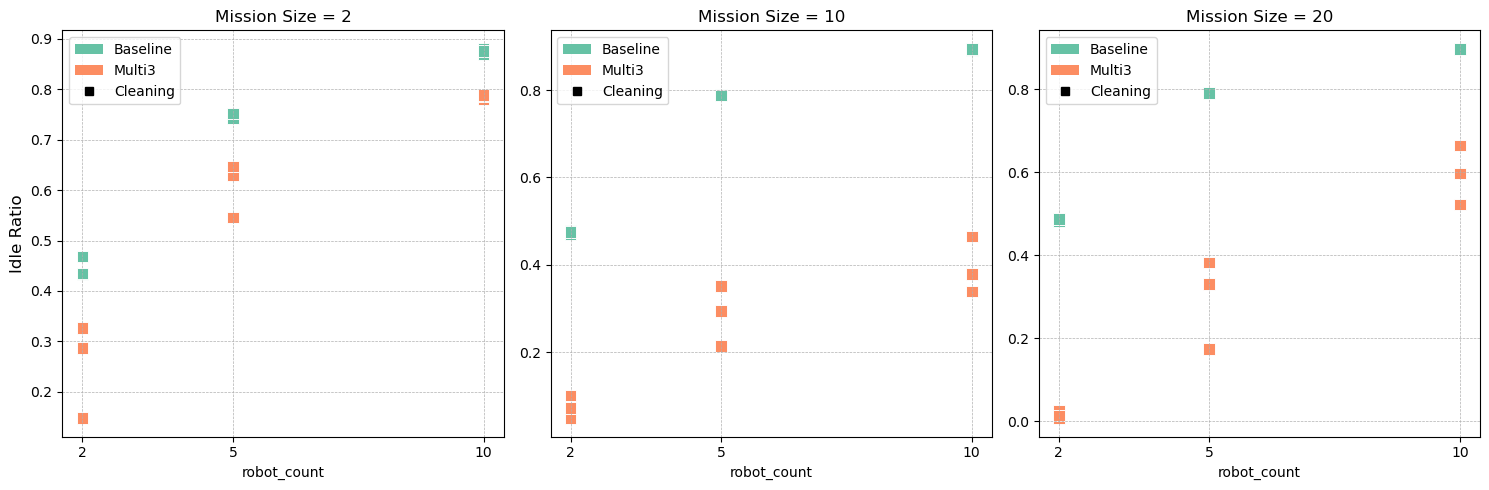

In [24]:
def multiplot_columns(df, fname, external_variable, var_x, baseline_col, multi3_col, title, x_label, y_label):
    marker_dict = {
        "agriculture": "o",
        "cleaning": "s",
        "logistics": "^",
        "surveillance": "D",
        "other": "v"
    }

    palette = sns.color_palette("Set2")
    approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(5 * len(external_variable_values), 5), squeeze=False)
    axes = axes[0]

    for i, v in enumerate(external_variable_values):
        ax = axes[i]

        x_df = df[df[external_variable] == v].copy()

        x_df = x_df.melt(id_vars=[var_x, "scenario", "inventory_id"], value_vars=[baseline_col, multi3_col], var_name="Approach", value_name="metric_value")

        x_df["Approach"] = x_df["Approach"].replace({baseline_col: "Baseline", multi3_col: "Multi3" })

        for approach in ["Baseline", "Multi3"]:
            approach_df = x_df[x_df["Approach"] == approach]

            sns.scatterplot(
                data=approach_df,
                x=var_x,
                y="metric_value",
                style="scenario",
                color=approach_colors[approach],
                ax=ax,
                markers=marker_dict,
                s=70
            )

        ax.set_title(title.replace("$field$", str(v)))
        ax.set_ylabel(y_label, fontsize=12)
        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")
        ax.set_xticks(sorted(x_df[var_x].unique()))
        ax.grid(True, linestyle="--", linewidth=0.5)

        color_handles = [
            Patch(facecolor=approach_colors["Baseline"], label="Baseline"),
            Patch(facecolor=approach_colors["Multi3"], label="Multi3")
        ]

        scenario_values = sorted(df["scenario"].unique())
        marker_handles = [
            Line2D(
                [0], [0],
                marker=marker_dict.get(s, marker_dict["other"]),
                color="black",
                linestyle="None",
                label=s.capitalize()
            )
            for s in scenario_values
        ]

        ax.legend(handles=color_handles + marker_handles, frameon=True)

    plt.tight_layout()
    plt.savefig(fname, format="pdf", bbox_inches="tight")
    plt.show()

multiplot_columns(idle_times_df, "../output/multi-mission/online-income/images/ir_by_mission_size_scatter.pdf", "robot_count", "mission_size", "idle_ratio_baseline", "idle_ratio_multi3", "Robot Count = $field$","Mission Size", "Idle Ratio")
multiplot_columns(idle_times_df, "../output/multi-mission/online-income/images/ir_by_robot_count_scatter.pdf", "mission_size", "robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "Mission Size = $field$","Robot Count", "Idle Ratio")

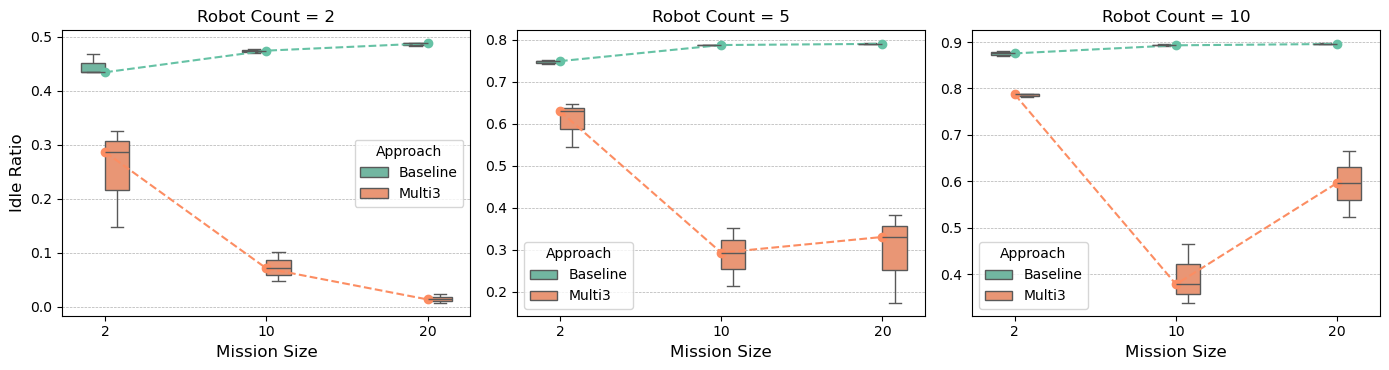

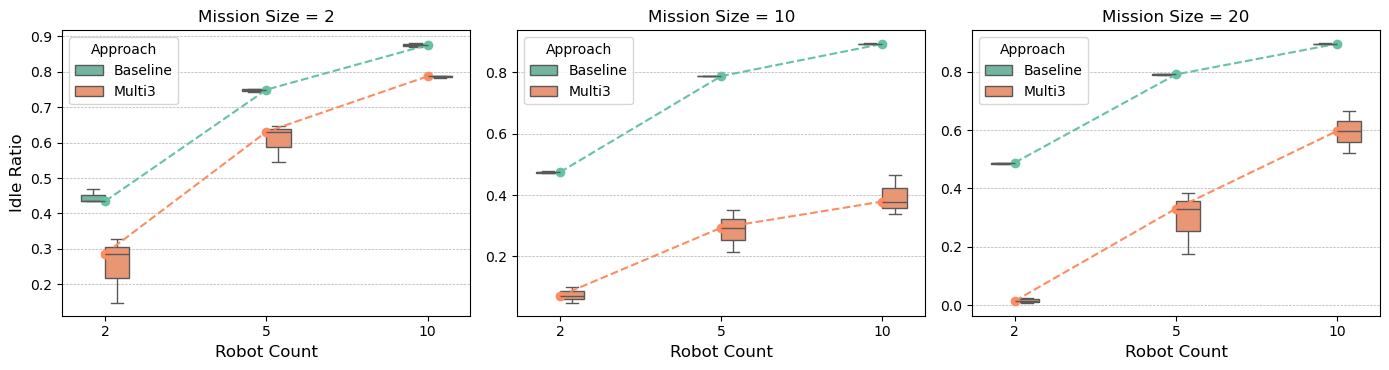

In [25]:
def multi_box_plot_columns(df, output_file_name, external_variable, var_x, baseline_col, multi3_col, external_variable_label, x_label, y_label):
    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(14, 4), squeeze=False)
    axes = axes[0]

    for i, external_variable_value in enumerate(external_variable_values):
        ax = axes[i]

        xx_df = df[df[external_variable] == external_variable_value].copy()
        xx_df = xx_df.melt( id_vars=[var_x], value_vars=[baseline_col, multi3_col], var_name="Approach", value_name="metric_value")
        xx_df["Approach"] = xx_df["Approach"].replace({baseline_col: "Baseline", multi3_col: "Multi3"})

        sns.boxplot(data=xx_df, x=var_x, y="metric_value", hue="Approach", palette=approach_colors, width=0.3, ax=ax)

        var_x_values = sorted(xx_df[var_x].unique())
        x_ticks = range(len(var_x_values))

        for approach, color in approach_colors.items():
            medians = []
            for x_val in var_x_values:
                values = xx_df[
                    (xx_df[var_x] == x_val) &
                    (xx_df["Approach"] == approach)
                ]["metric_value"]

                medians.append(np.median(values) if not values.empty else np.nan)

            ax.plot(x_ticks, medians, marker="o", linestyle="--", color=color)

        ax.set_title(f"{external_variable_label} = {external_variable_value}")
        ax.set_xlabel(x_label, fontsize=12)

        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")

        ax.yaxis.grid(True, linestyle="--", linewidth=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_file_name, format="pdf", bbox_inches="tight")
    plt.show()

multi_box_plot_columns(idle_times_df, "../output/multi-mission/online-income/images/ir_by_mission_size_box.pdf", "robot_count", "mission_size", "idle_ratio_baseline", "idle_ratio_multi3", "Robot Count", "Mission Size", "Idle Ratio")
multi_box_plot_columns(idle_times_df, "../output/multi-mission/online-income/images/ir_by_robot_count_box.pdf", "mission_size", "robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "Mission Size", "Robot Count", "Idle Ratio")

#### Computing idle time ratio difference percentages per configuration

In [26]:
idle_ratio_stats = (
    idle_times_df.groupby(["mission_size", "robot_count"])
    .agg({
        "idle_ratio_baseline": ["mean"],
        "idle_ratio_multi3": ["mean"],
        "idle_ratio_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

idle_ratio_stats.columns = ["mission_size", "robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "min_idle_ratio_diff_percentage", "max_idle_ratio_diff_percentage", "mean_idle_ratio_diff_percentage", "median_idle_ratio_diff_percentage"]

idle_ratio_stats

,mission_size,robot_count,idle_ratio_baseline,idle_ratio_multi3,min_idle_ratio_diff_percentage,max_idle_ratio_diff_percentage,mean_idle_ratio_diff_percentage,median_idle_ratio_diff_percentage
0,2,2,0.445668,0.253674,-65.967895,-24.787935,-43.184727,-38.798350
1,2,5,0.748113,0.607910,-27.400687,-12.857509,-18.712644,-15.879734
2,2,10,0.875142,0.785800,-10.577772,-9.899955,-10.208009,-10.146300
3,10,2,0.474012,0.073678,-89.800142,-78.555823,-84.429235,-84.931739
4,10,5,0.787894,0.286408,-72.838494,-55.332445,-63.649690,-62.778130
5,10,10,0.893276,0.394245,-61.992355,-47.936194,-55.865668,-57.668456
6,20,2,0.486075,0.015499,-98.391846,-94.877744,-96.803685,-97.141466
7,20,5,0.790724,0.295736,-78.021416,-51.567770,-62.586520,-58.170374
8,20,10,0.896284,0.594723,-41.747382,-25.820434,-33.641543,-33.356814


In [27]:
idle_ratio_stats = (
    idle_times_df.groupby(["mission_size"])
    .agg({
        "idle_ratio_baseline": ["mean"],
        "idle_ratio_multi3": ["mean"],
        "idle_ratio_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

idle_ratio_stats.columns = ["mission_size", "idle_ratio_baseline", "idle_ratio_multi3", "min_idle_ratio_diff_percentage", "max_idle_ratio_diff_percentage", "mean_idle_ratio_diff_percentage", "median_idle_ratio_diff_percentage"]

idle_ratio_stats

,mission_size,idle_ratio_baseline,idle_ratio_multi3,min_idle_ratio_diff_percentage,max_idle_ratio_diff_percentage,mean_idle_ratio_diff_percentage,median_idle_ratio_diff_percentage
0,2,0.689641,0.549128,-65.967895,-9.899955,-24.035126,-15.879734
1,10,0.718394,0.251444,-89.800142,-47.936194,-67.981531,-62.778130
2,20,0.724361,0.301986,-98.391846,-25.820434,-64.343916,-58.170374


In [28]:
idle_ratio_stats = (
    idle_times_df.groupby(["robot_count"])
    .agg({
        "idle_ratio_baseline": ["mean"],
        "idle_ratio_multi3": ["mean"],
        "idle_ratio_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

idle_ratio_stats.columns = ["robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "min_idle_ratio_diff_percentage", "max_idle_ratio_diff_percentage", "mean_idle_ratio_diff_percentage", "median_idle_ratio_diff_percentage"]

idle_ratio_stats

,robot_count,idle_ratio_baseline,idle_ratio_multi3,min_idle_ratio_diff_percentage,max_idle_ratio_diff_percentage,mean_idle_ratio_diff_percentage,median_idle_ratio_diff_percentage
0,2,0.468585,0.114284,-98.391846,-24.787935,-74.805882,-84.931739
1,5,0.775577,0.396685,-78.021416,-12.857509,-48.316284,-55.332445
2,10,0.888234,0.591589,-61.992355,-9.899955,-33.238407,-33.356814


#### Computing idle time ratio averages per scenario

In [29]:
idle_times_average_df = (
    idle_times_df.groupby("scenario")
      .agg({
          "average_robot_idle_time_baseline": "mean",
          "average_robot_idle_time_multi3": "mean",
          "average_robot_idle_time_diff_percentage": "mean",
          "idle_ratio_baseline": "mean",
          "idle_ratio_multi3": "mean",
          "idle_ratio_diff_percentage": "mean"
      })
      .reset_index()
)

idle_times_average_df.rename(columns={"average_robot_idle_time_diff_percentage": "average_of_average_robot_idle_time_diff_percentage", "idle_ratio_diff_percentage": "average_of_idle_ratio_diff_percentage"}, inplace=True)

idle_times_average_df["diff_percentage_on_average_robot_idle_time"] = (idle_times_average_df["average_robot_idle_time_multi3"] - idle_times_average_df["average_robot_idle_time_baseline"]) / idle_times_average_df["average_robot_idle_time_baseline"] * 100

idle_times_average_df["diff_percentage_on_average_ratios"] = (idle_times_average_df["idle_ratio_multi3"] - idle_times_average_df["idle_ratio_baseline"]) / idle_times_average_df["idle_ratio_baseline"] * 100

idle_times_average_df

,scenario,average_robot_idle_time_baseline,average_robot_idle_time_multi3,average_of_average_robot_idle_time_diff_percentage,idle_ratio_baseline,idle_ratio_multi3,average_of_idle_ratio_diff_percentage,diff_percentage_on_average_robot_idle_time,diff_percentage_on_average_ratios
0,cleaning,361.572537,45.656657,-75.924796,0.710799,0.367519,-52.120191,-87.372753,-48.294884


#### Plotting average idle times per scenario

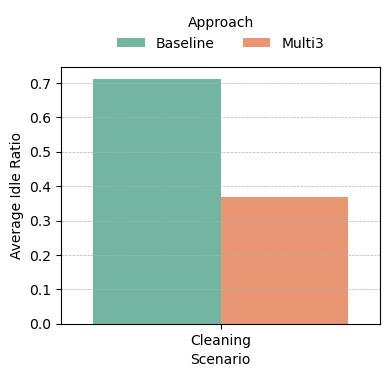

In [30]:
melted = idle_times_average_df.melt(id_vars='scenario', value_vars=['idle_ratio_baseline', 'idle_ratio_multi3'], var_name='mode', value_name='coefficient')

melted['mode'] = melted['mode'].replace({'idle_ratio_baseline': 'Baseline', 'idle_ratio_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='coefficient', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Average Idle Ratio')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/multi-mission/online-income/images/ir_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Wilcoxon test on paired differences

In [31]:
## Wilcoxon signed-rank test for idle ratio differences (on paired samples, to check if the differences are statistically significant, we want to test if multi3 is significantly lower than baseline)
wilcoxon_test = wilcoxon(idle_times_df['idle_ratio_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on idle ratio:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test on idle ratio:
Statistic: 0.0, p-value: 1.4901161193847656e-08


In [32]:
median_idle_ratio = idle_times_df['idle_ratio_paired_diff'].median()
percentile_5_idle_ratio = idle_times_df['idle_ratio_paired_diff'].quantile(0.05)

print(f"Idle ratio paired difference median: {median_idle_ratio}")
print(f"5th percentile: {percentile_5_idle_ratio}")

Idle ratio paired difference median: 0.4029924671848718
5th percentile: 0.08969356644638081


## EQ4 (first part): Analyzing workload variance

Metric:

$WorkloadVariance = \frac{1}{|R|} \sum_{r \in R}​(W_r ​ − \overline{W})^2$

where: $\overline{W} = \frac{1}{|R|} \sum_{r \in R}​W_r$, and $W_r$ is the active time of robot $r \in R$

$CV = \frac{\sqrt{WorkloadVariance}}{\overline{W}}$

In [33]:
workload_df = mission_data_df.copy()

workload_df["workload"] = workload_df["makespan"] - workload_df["robot_idle_time"]

workload_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,makespan,robot_id,robot_idle_time,workload
0,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_1,410.642433,595.866166
1,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_2,619.125929,387.382670
2,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_3,992.985163,13.523436
3,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_4,976.456206,30.052392
4,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1006.508599,robot_5,983.995521,22.513078
...,...,...,...,...,...,...,...,...,...,...
607,test-multi_2_10_t_cleaning_i2_bl1,2,10,2,cleaning,bl1,475.506605,robot_2,283.424830,192.081775
608,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,117.010583,robot_1,29.997663,87.012919
609,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,117.010583,robot_2,68.997043,48.013540
610,test-multi_2_20_t_cleaning_i1_multi3,2,20,1,cleaning,multi3,576.021816,robot_1,6.018667,570.003150


In [34]:
group_cols = ["robot_count", "mission_size", "inventory_id", "scenario", "mode"]
workload_variance_df = (
    workload_df
    .groupby(group_cols)
    .agg(
        workload_mean=("workload", "mean"),
        workload_var=("workload", lambda x: x.var(ddof=0)),
        workload_std=("workload", lambda x: x.std(ddof=0))
    )
    .reset_index()
)

workload_variance_df["workload_cv"] = workload_variance_df["workload_std"] / workload_variance_df["workload_mean"]

workload_variance_df

,robot_count,mission_size,inventory_id,scenario,mode,workload_mean,workload_var,workload_std,workload_cv
0,2,2,0,cleaning,bl0,67.548641,2.354375,1.534397,0.022715
1,2,2,0,cleaning,bl1,67.513229,380.237898,19.499690,0.288828
2,2,2,0,cleaning,bl2,64.490027,225.306452,15.010212,0.232752
3,2,2,0,cleaning,multi3,72.755659,297.355214,17.243991,0.237012
4,2,2,1,cleaning,bl0,69.005149,20.218089,4.496453,0.065161
...,...,...,...,...,...,...,...,...,...
103,10,20,1,cleaning,multi3,46.315981,240.301316,15.501655,0.334693
104,10,20,2,cleaning,bl0,84.453853,51513.786239,226.966487,2.687462
105,10,20,2,cleaning,bl1,84.128727,54311.959005,233.049263,2.770151
106,10,20,2,cleaning,bl2,84.741242,54915.988204,234.341606,2.765378


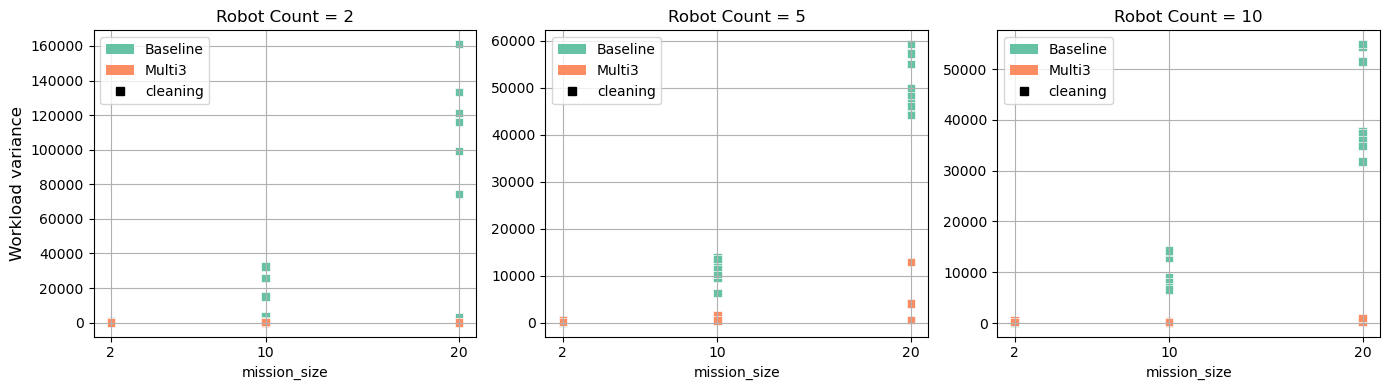

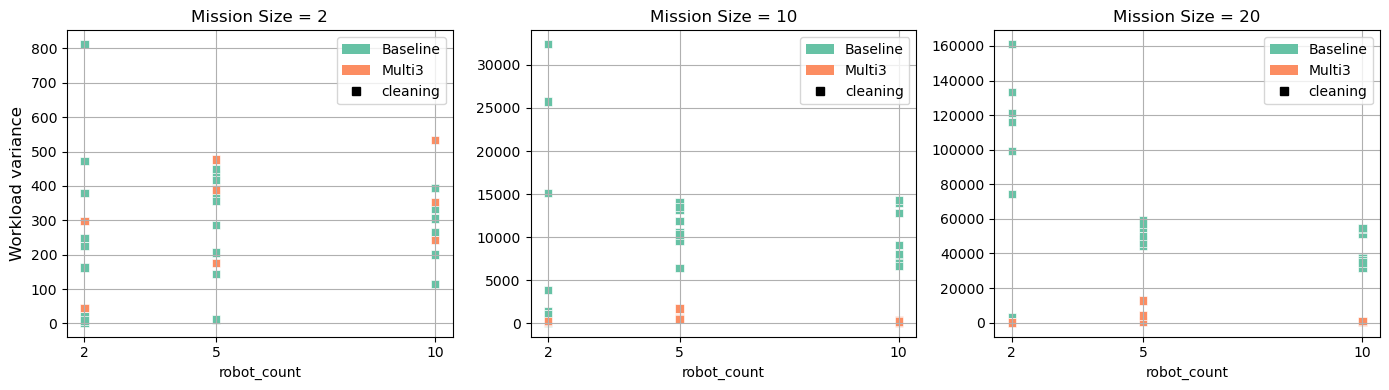

In [35]:
multiplot(workload_variance_df, "../output/multi-mission/online-income/images/wv_by_mission_size_scatter.pdf", "robot_count", "mission_size","workload_var","Robot Count = $field$", "Mission Size", "Workload variance")
multiplot(workload_variance_df, "../output/multi-mission/online-income/images/wv_by_robot_count_scatter.pdf", "mission_size", "robot_count","workload_var","Mission Size = $field$", "Robot Count", "Workload variance")

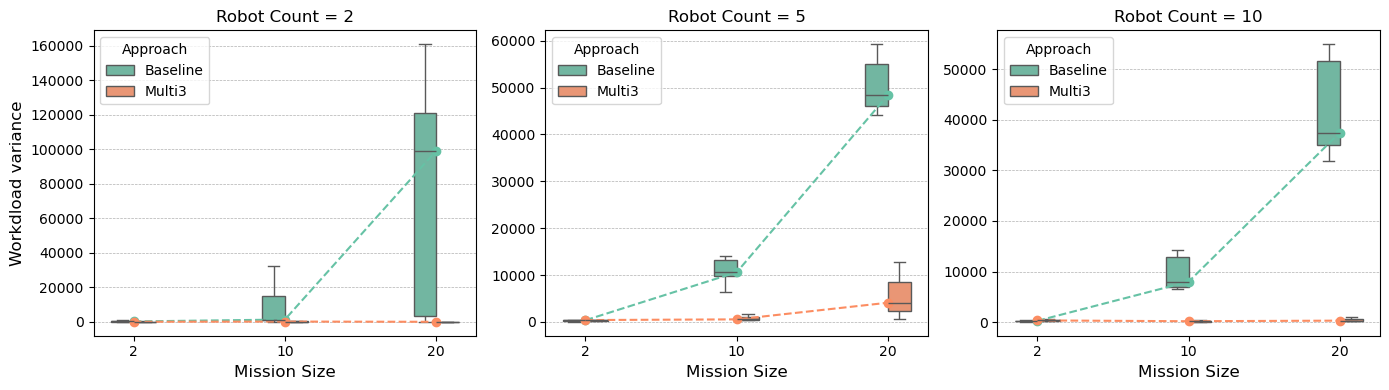

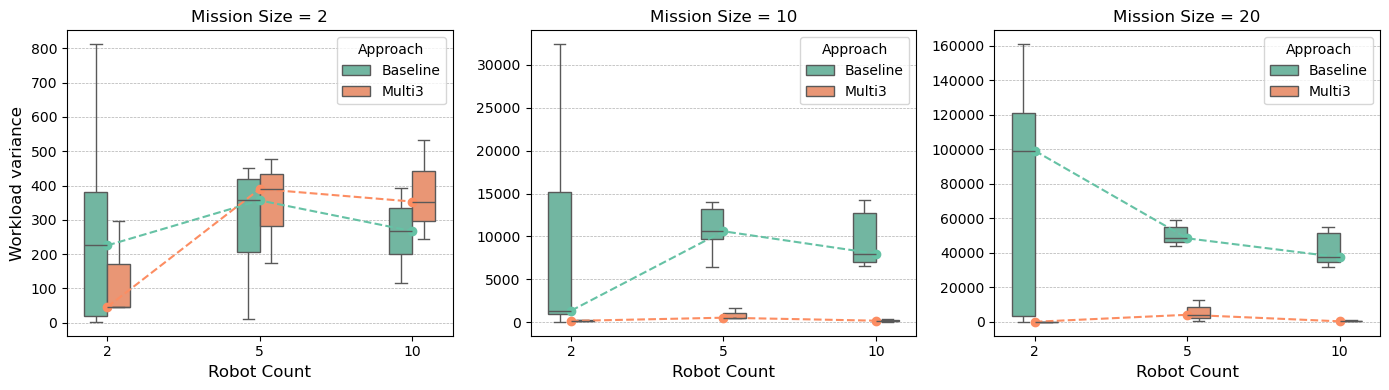

In [36]:
multi_box_plot(workload_variance_df, "../output/multi-mission/online-income/images/wv_by_mission_size_box.pdf", "robot_count", "mission_size", "workload_var", "Robot Count", "Mission Size", "Workdload variance")
multi_box_plot(workload_variance_df, "../output/multi-mission/online-income/images/wv_by_robot_count_box.pdf", "mission_size", "robot_count", "workload_var", "Mission Size", "Robot Count", "Workload variance")

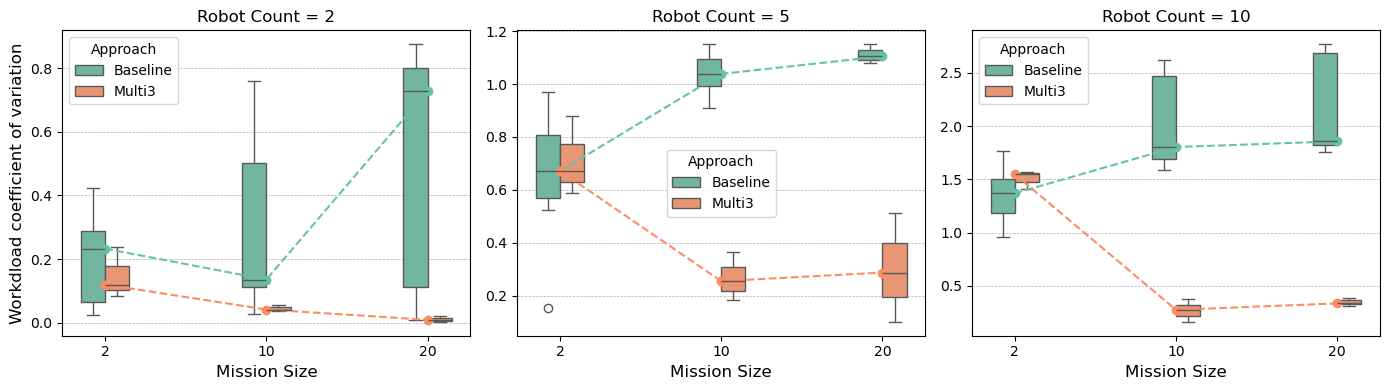

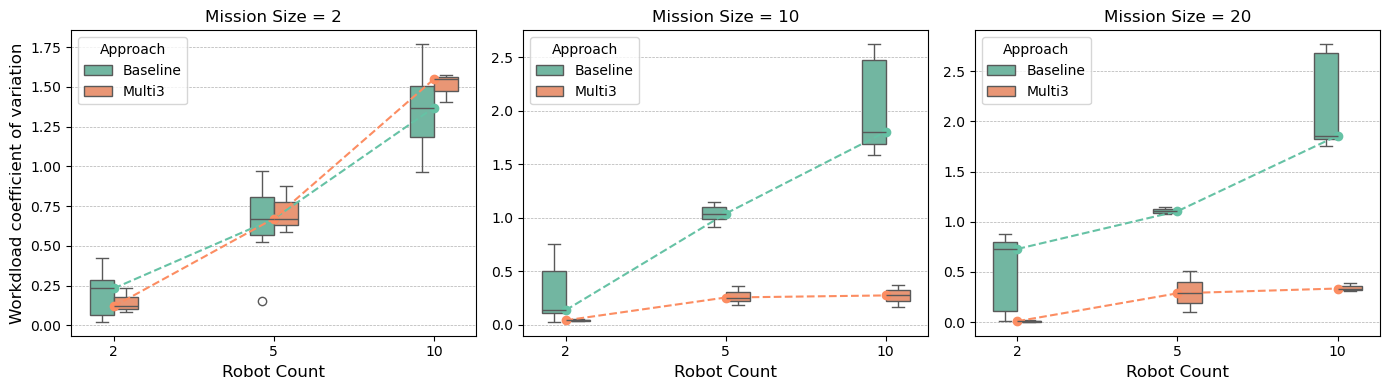

In [37]:
multi_box_plot(workload_variance_df, "../output/multi-mission/online-income/images/cv_by_mission_size_box.pdf", "robot_count", "mission_size", "workload_cv", "Robot Count", "Mission Size", "Workdload coefficient of variation")
multi_box_plot(workload_variance_df, "../output/multi-mission/online-income/images/cv_by_robot_count_box.pdf", "mission_size", "robot_count", "workload_cv", "Mission Size", "Robot Count", "Workdload coefficient of variation")

In [38]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_workload_baseline = workload_variance_df[workload_variance_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_workload_baseline_avg = (
    df_workload_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "workload_var": "mean",
        "workload_std": "mean",
        "workload_cv": "mean"
    })
)

df_workload_baseline_avg["mode"] = "baseline"

df_workload_multi3 = workload_variance_df[workload_variance_df["mode"] == "multi3"].copy()

df_workload_grouped = pd.concat([df_workload_baseline_avg, df_workload_multi3], ignore_index=True)

df_workload_grouped = df_workload_grouped[group_cols + ["mode", "workload_var", "workload_std", "workload_cv"]]
df_workload_grouped

,scenario,robot_count,mission_size,inventory_id,mode,workload_var,workload_std,workload_cv
0,cleaning,2,2,0,baseline,202.632908,12.014766,0.181432
1,cleaning,2,2,1,baseline,360.201049,16.249141,0.242931
2,cleaning,2,2,2,baseline,214.751275,12.493004,0.232141
3,cleaning,2,10,0,baseline,24431.712604,154.505406,0.642368
4,cleaning,2,10,1,baseline,799.845559,25.253504,0.092165
5,cleaning,2,10,2,baseline,1801.666945,38.987548,0.153482
6,cleaning,2,20,0,baseline,1071.029323,22.000657,0.043668
7,cleaning,2,20,1,baseline,98287.320485,312.001845,0.726448
8,cleaning,2,20,2,baseline,136781.200685,368.998209,0.806489
9,cleaning,5,2,0,baseline,338.490760,18.188611,0.670314


In [39]:
pivot_workload_df = df_workload_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["workload_var", "workload_std", "workload_cv"]
)

pivot_workload_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_workload_df.columns]

pivot_workload_df = pivot_workload_df.reset_index()

pivot_workload_df["workload_var_diff_percentage"] = (
    (pivot_workload_df["workload_var_multi3"] - pivot_workload_df["workload_var_baseline"])
    / pivot_workload_df["workload_var_baseline"]
) * 100

pivot_workload_df["workload_var_paired_diff"] = pivot_workload_df["workload_var_baseline"] - pivot_workload_df["workload_var_multi3"]

pivot_workload_df["workload_cv_diff_percentage"] = (
    (pivot_workload_df["workload_cv_multi3"] - pivot_workload_df["workload_cv_baseline"])
    / pivot_workload_df["workload_cv_baseline"]
) * 100

pivot_workload_df["workload_cv_paired_diff"] = pivot_workload_df["workload_cv_baseline"] - pivot_workload_df["workload_cv_multi3"]

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "workload_var_baseline",
    "workload_var_multi3",
    "workload_var_diff_percentage",
    "workload_var_paired_diff",
    "workload_std_baseline",
    "workload_std_multi3",
    "workload_cv_baseline",
    "workload_cv_multi3",
    "workload_cv_diff_percentage",
    "workload_cv_paired_diff"
]

pivot_workload_df = pivot_workload_df[ordered_cols]

pivot_workload_df

,scenario,robot_count,mission_size,inventory_id,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_var_paired_diff,workload_std_baseline,workload_std_multi3,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage,workload_cv_paired_diff
0,cleaning,2,2,0,202.632908,297.355214,46.745766,-94.722306,12.014766,17.243991,0.181432,0.237012,30.634369,-0.055581
1,cleaning,2,2,1,360.201049,45.642978,-87.328472,314.558072,16.249141,6.755959,0.242931,0.084182,-65.347279,0.158749
2,cleaning,2,2,2,214.751275,45.482492,-78.820851,169.268783,12.493004,6.744071,0.232141,0.119881,-48.358488,0.112260
3,cleaning,2,10,0,24431.712604,162.452455,-99.335075,24269.260149,154.505406,12.745684,0.642368,0.041348,-93.563113,0.601019
4,cleaning,2,10,1,799.845559,144.253541,-81.964826,655.592018,25.253504,12.010560,0.092165,0.037416,-59.403373,0.054749
5,cleaning,2,10,2,1801.666945,272.137101,-84.895260,1529.529844,38.987548,16.496578,0.153482,0.056399,-63.253507,0.097082
6,cleaning,2,20,0,1071.029323,126.305013,-88.207138,944.724310,22.000657,11.238550,0.043668,0.019953,-54.307521,0.023715
7,cleaning,2,20,1,98287.320485,2.242421,-99.997719,98285.078064,312.001845,1.497472,0.726448,0.002620,-99.639308,0.723828
8,cleaning,2,20,2,136781.200685,27.469196,-99.979917,136753.731489,368.998209,5.241106,0.806489,0.008971,-98.887674,0.797518
9,cleaning,5,2,0,338.490760,390.018873,15.222901,-51.528113,18.188611,19.748895,0.670314,0.672130,0.270798,-0.001815


#### Cleaning from outliers

In [40]:
numeric_cols = pivot_workload_df.select_dtypes(include=np.number).columns
negative_rows = pivot_workload_df[(pivot_workload_df[numeric_cols] > 0).any(axis=1)]
negative_rows

,scenario,robot_count,mission_size,inventory_id,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_var_paired_diff,workload_std_baseline,workload_std_multi3,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage,workload_cv_paired_diff
0,cleaning,2,2,0,202.632908,297.355214,46.745766,-94.722306,12.014766,17.243991,0.181432,0.237012,30.634369,-0.055581
1,cleaning,2,2,1,360.201049,45.642978,-87.328472,314.558072,16.249141,6.755959,0.242931,0.084182,-65.347279,0.158749
2,cleaning,2,2,2,214.751275,45.482492,-78.820851,169.268783,12.493004,6.744071,0.232141,0.119881,-48.358488,0.112260
3,cleaning,2,10,0,24431.712604,162.452455,-99.335075,24269.260149,154.505406,12.745684,0.642368,0.041348,-93.563113,0.601019
4,cleaning,2,10,1,799.845559,144.253541,-81.964826,655.592018,25.253504,12.010560,0.092165,0.037416,-59.403373,0.054749
5,cleaning,2,10,2,1801.666945,272.137101,-84.895260,1529.529844,38.987548,16.496578,0.153482,0.056399,-63.253507,0.097082
6,cleaning,2,20,0,1071.029323,126.305013,-88.207138,944.724310,22.000657,11.238550,0.043668,0.019953,-54.307521,0.023715
7,cleaning,2,20,1,98287.320485,2.242421,-99.997719,98285.078064,312.001845,1.497472,0.726448,0.002620,-99.639308,0.723828
8,cleaning,2,20,2,136781.200685,27.469196,-99.979917,136753.731489,368.998209,5.241106,0.806489,0.008971,-98.887674,0.797518
9,cleaning,5,2,0,338.490760,390.018873,15.222901,-51.528113,18.188611,19.748895,0.670314,0.672130,0.270798,-0.001815


#### Computing averages per configuration

In [41]:
workload_average_df = (
    pivot_workload_df.groupby(["mission_size", "robot_count"])
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.columns = ["mission_size", "robot_count", "workload_var_baseline", "workload_var_multi3", "workload_var_diff_percentage", "workload_cv_baseline", "workload_cv_multi3", "workload_cv_diff_percentage"]

workload_average_df

,mission_size,robot_count,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,2,2,259.195078,129.493561,-39.801186,0.218835,0.147025,-27.690466
1,2,5,297.851965,347.517434,14.031228,0.660729,0.713022,8.808017
2,2,10,264.560601,376.545605,40.031248,1.351512,1.508653,11.619162
3,10,2,9011.075036,192.947699,-88.731721,0.296005,0.045055,-72.073331
4,10,5,11021.890862,898.596878,-91.604970,1.039247,0.267002,-74.259158
5,10,10,9561.011279,208.679563,-97.651322,1.990557,0.269332,-85.948068
6,20,2,78713.183498,52.005543,-96.061591,0.525535,0.010515,-84.278167
7,20,5,50275.377750,5841.828267,-89.251781,1.110478,0.299939,-73.177990
8,20,10,41519.943715,503.185262,-98.886046,2.136922,0.346652,-83.452446


In [42]:
workload_average_df = (
    pivot_workload_df.groupby(["robot_count"])
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.columns = ["robot_count", "workload_var_baseline", "workload_var_multi3", "workload_var_diff_percentage", "workload_cv_baseline", "workload_cv_multi3", "workload_cv_diff_percentage"]

workload_average_df

,robot_count,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,2,29327.817870,124.815601,-74.864832,0.346792,0.067531,-61.347321
1,5,20531.706859,2362.647526,-55.608508,0.936818,0.426654,-46.209711
2,10,17115.171865,362.803477,-52.168706,1.826330,0.708212,-52.593784


In [43]:
workload_average_df = (
    pivot_workload_df.groupby(["mission_size"])
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.columns = ["mission_size", "workload_var_baseline", "workload_var_multi3", "workload_var_diff_percentage", "workload_cv_baseline", "workload_cv_multi3", "workload_cv_diff_percentage"]

workload_average_df

,mission_size,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,2,273.869215,284.518867,4.753763,0.743692,0.789567,-2.421096
1,10,9864.659059,433.408047,-92.662671,1.108603,0.193796,-77.426852
2,20,56836.168321,2132.339691,-94.733139,1.257645,0.219035,-80.302868


#### Computing averages per scenario

In [44]:
workload_average_df = (
    pivot_workload_df.groupby("scenario")
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_std_baseline": "mean",
          "workload_std_multi3": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
      .reset_index()
)

workload_average_df.rename(columns={"workload_var_diff_percentage": "average_of_workload_var_diff_percentage", "workload_cv_diff_percentage": "average_of_workload_cv_diff_percentage"}, inplace=True)

workload_average_df["diff_percentage_on_average_workload_var"] = (workload_average_df["workload_var_multi3"] - workload_average_df["workload_var_baseline"]) / workload_average_df["workload_var_baseline"] * 100
workload_average_df["diff_percentage_on_average_workload_cv"] = (workload_average_df["workload_cv_multi3"] - workload_average_df["workload_cv_baseline"]) / workload_average_df["workload_cv_baseline"] * 100

workload_average_df

,scenario,workload_var_baseline,workload_var_multi3,average_of_workload_var_diff_percentage,workload_std_baseline,workload_std_multi3,workload_cv_baseline,workload_cv_multi3,average_of_workload_cv_diff_percentage,diff_percentage_on_average_workload_var,diff_percentage_on_average_workload_cv
0,cleaning,22324.898865,950.088868,-60.880682,108.975024,22.037776,1.036647,0.400799,-53.383605,-95.744264,-61.336939


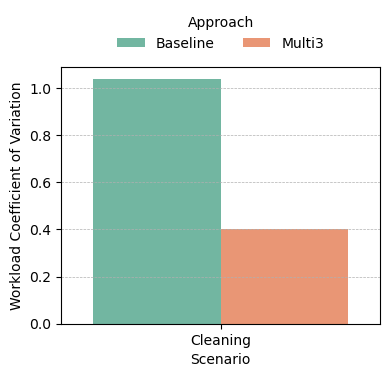

In [45]:
melted = workload_average_df.melt(id_vars='scenario', value_vars=['workload_cv_baseline', 'workload_cv_multi3'], var_name='mode', value_name='coefficient')

melted['mode'] = melted['mode'].replace({'workload_cv_baseline': 'Baseline', 'workload_cv_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='coefficient', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Workload Coefficient of Variation')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/multi-mission/online-income/images/cv_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Wilcoxon test on paired differences

In [46]:
wilcoxon_test = wilcoxon(pivot_workload_df['workload_var_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on Workload variance:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test on Workload variance:
Statistic: 29.0, p-value: 2.586841583251953e-05


In [47]:
# Checking only with mission_size = 2
wilcoxon_test_mission_size_2 = wilcoxon(pivot_workload_df[pivot_workload_df['mission_size'] == 2]['workload_var_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on Workload variance (mission_size = 2):\nStatistic: {wilcoxon_test_mission_size_2.statistic}, p-value: {wilcoxon_test_mission_size_2.pvalue}")

Wilcoxon signed-rank test on Workload variance (mission_size = 2):
Statistic: 16.0, p-value: 0.49609375


In [48]:
median_workload_var = pivot_workload_df['workload_var_paired_diff'].median()
percentile_5_workload_var = pivot_workload_df['workload_var_paired_diff'].quantile(0.05)

print(f"Workload variance paired difference median: {median_workload_var}")
print(f"5th percentile: {percentile_5_workload_var}")

Workload variance paired difference median: 7439.77752154387
5th percentile: -117.64593357777264


In [49]:
wilcoxon_test = wilcoxon(pivot_workload_df['workload_cv_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on Workload coefficient of variation:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test on Workload coefficient of variation:
Statistic: 47.0, p-value: 0.0003008991479873657


In [50]:
median_workload_cv = pivot_workload_df['workload_cv_paired_diff'].median()
percentile_5_workload_cv = pivot_workload_df['workload_cv_paired_diff'].quantile(0.05)

print(f"Workload coefficient of variation paired difference median: {median_workload_cv}")
print(f"5th percentile: {percentile_5_workload_cv}")

Workload coefficient of variation paired difference median: 0.6203027466142422
5th percentile: -0.1338923483827685


In [51]:
# Checking only with mission_size = 2
wilcoxon_test_mission_size_2 = wilcoxon(pivot_workload_df[pivot_workload_df['mission_size'] == 2]['workload_cv_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on Workload coefficient of variation (mission_size = 2):\nStatistic: {wilcoxon_test_mission_size_2.statistic}, p-value: {wilcoxon_test_mission_size_2.pvalue}")

Wilcoxon signed-rank test on Workload coefficient of variation (mission_size = 2):
Statistic: 13.0, p-value: 0.30078125


## EQ4 (second part): Analyzing concurrency ratio

## Metric

$CR = \frac{1}{T} \int_0^T A(t)\, dt$,

where $T$ is the mission completion time, and $A(t) = |\{r \in R | r$ is executing a task at time $t\}|$.

In [52]:
with open("../output/multi-mission/online-income/robot_data.json", 'r') as f:
    robot_execution_data = json.load(f)

In [53]:
results = []

for mission_id, mission_data in robot_execution_data.items():
    T = mission_data["mission_duration"]
    robots = mission_data["robots"]

    labels = mission_id.split("_")
    robot_count = int(labels[1])
    mission_size = int(labels[2])
    inv_id = int(labels[5][1])
    scenario = labels[4]
    mode = labels[6]

    total_active_time = 0

    for robot_name, robot_data in robots.items():
        intervals = robot_data["non_idle_intervals"]

        robot_active_time = sum(interval[1] for interval in intervals)
        total_active_time += robot_active_time

    cr = total_active_time / T if T > 0 else 0

    results.append({
        "scenario": scenario,
        "robot_count": robot_count,
        "mission_size": mission_size,
        "inventory_id": inv_id,
        "mode": mode,
        "mission_duration": T,
        "total_active_time": total_active_time,
        "CR": cr
    })

concurrency_ratio_df = pd.DataFrame(results)
concurrency_ratio_df

,scenario,robot_count,mission_size,inventory_id,mode,mission_duration,total_active_time,CR
0,cleaning,5,20,0,bl2,1006.508599,1049.337742,1.042552
1,cleaning,10,20,0,multi3,138.047498,556.333242,4.030013
2,cleaning,10,10,0,bl1,489.047070,525.813013,1.075179
3,cleaning,5,10,1,bl2,462.033109,496.522048,1.074646
4,cleaning,10,20,1,bl1,984.049014,1021.430999,1.037988
...,...,...,...,...,...,...,...,...
103,cleaning,10,2,0,bl1,76.505655,97.296310,1.271753
104,cleaning,10,2,0,bl0,79.505140,98.884510,1.243750
105,cleaning,2,10,2,bl1,475.506605,508.644173,1.069689
106,cleaning,2,2,0,bl1,117.010583,135.026459,1.153968


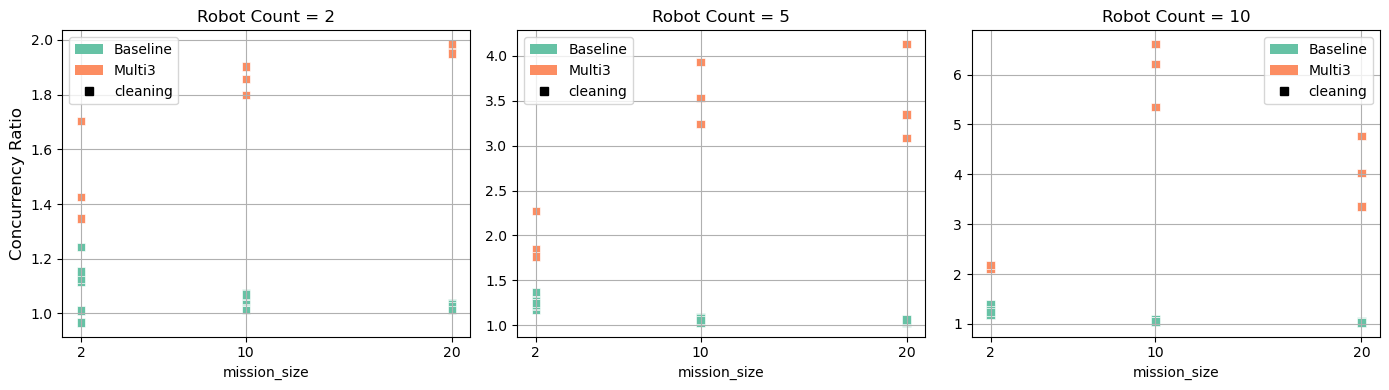

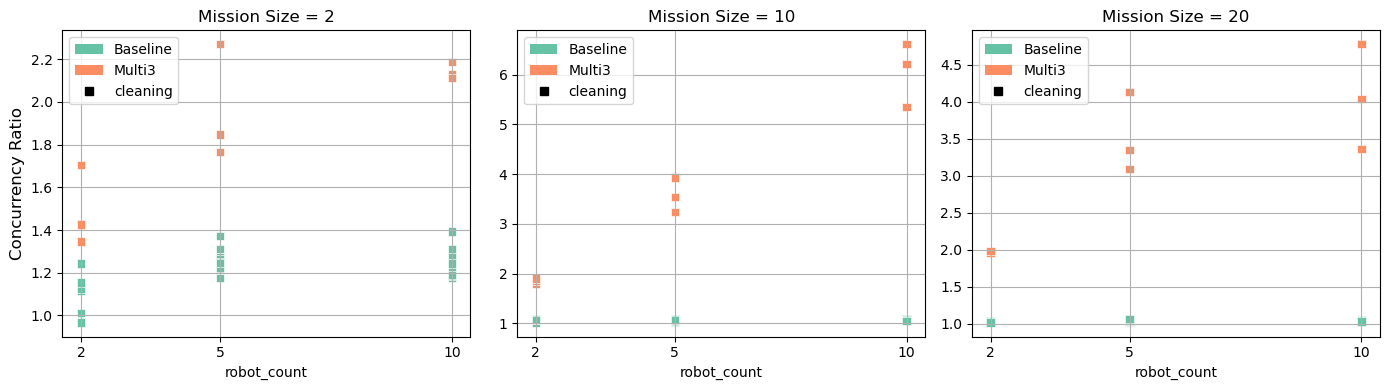

In [54]:
multiplot(concurrency_ratio_df, "../output/multi-mission/online-income/images/cr_by_mission_size_scatter.pdf", "robot_count", "mission_size","CR","Robot Count = $field$", "Mission Size", "Concurrency Ratio")
multiplot(concurrency_ratio_df, "../output/multi-mission/online-income/images/cr_by_robot_count_scatter.pdf", "mission_size", "robot_count","CR","Mission Size = $field$", "Robot Count", "Concurrency Ratio")

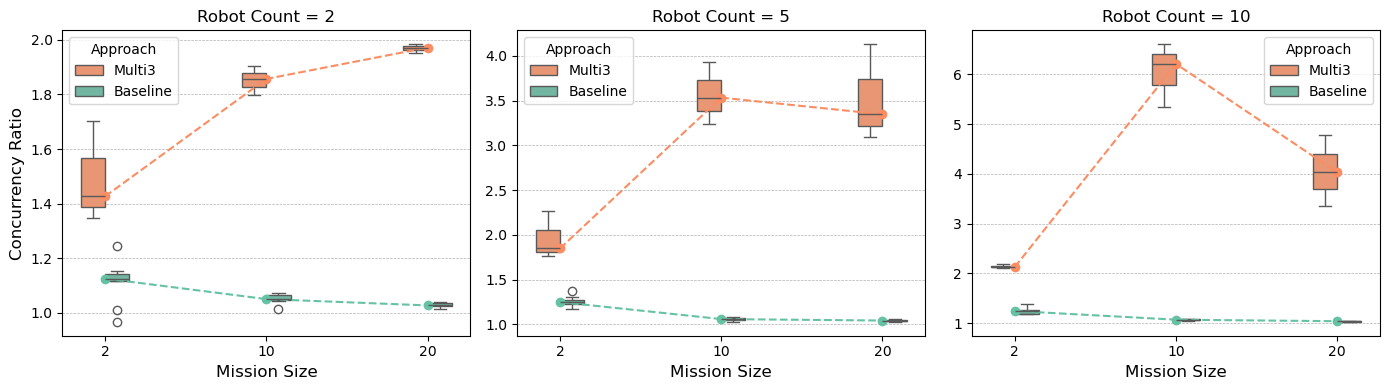

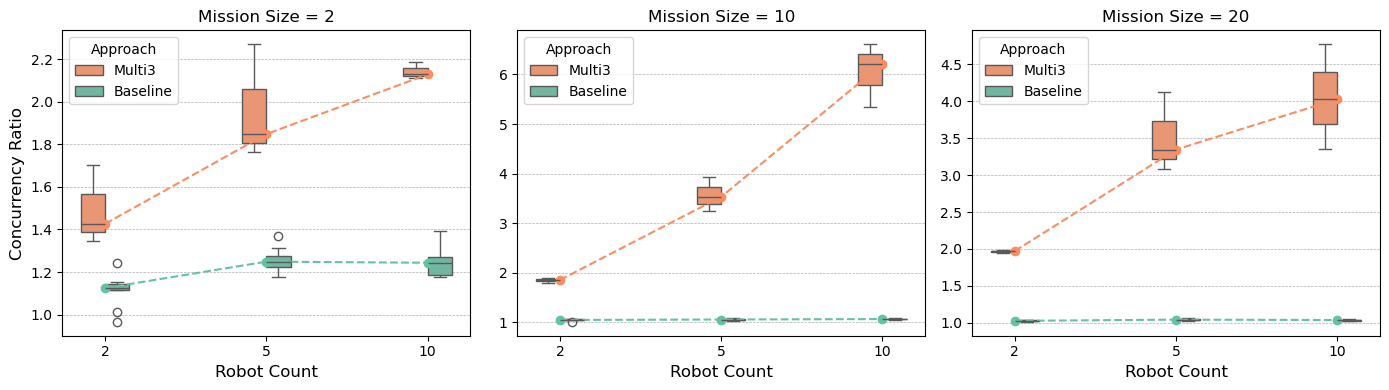

In [55]:
multi_box_plot(concurrency_ratio_df, "../output/multi-mission/online-income/images/cr_by_mission_size_box.pdf", "robot_count", "mission_size", "CR", "Robot Count", "Mission Size", "Concurrency Ratio")
multi_box_plot(concurrency_ratio_df, "../output/multi-mission/online-income/images/cr_by_robot_count_box.pdf", "mission_size", "robot_count", "CR", "Mission Size", "Robot Count", "Concurrency Ratio")

In [56]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_concurrency_baseline = concurrency_ratio_df[concurrency_ratio_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_concurrency_baseline_avg = (
    df_concurrency_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "mission_duration": "mean",
        "total_active_time": "mean",
        "CR": "mean"
    })
)

df_concurrency_baseline_avg["mode"] = "baseline"

df_concurrency_multi3 = concurrency_ratio_df[concurrency_ratio_df["mode"] == "multi3"].copy()

df_concurrency_grouped = pd.concat([df_concurrency_baseline_avg, df_concurrency_multi3], ignore_index=True)

df_concurrency_grouped = df_concurrency_grouped[group_cols + ["mode", "mission_duration", "total_active_time", "CR"]]
df_concurrency_grouped

,scenario,robot_count,mission_size,inventory_id,mode,mission_duration,total_active_time,CR
0,cleaning,2,2,0,baseline,117.532520,133.034598,1.131891
1,cleaning,2,2,1,baseline,126.512255,134.499938,1.073616
2,cleaning,2,2,2,baseline,95.507971,108.015792,1.131045
3,cleaning,2,10,0,baseline,461.006987,482.039271,1.045660
4,cleaning,2,10,1,baseline,518.014288,548.723505,1.059266
5,cleaning,2,10,2,baseline,483.512134,508.181084,1.051606
6,cleaning,2,20,0,baseline,965.009648,999.380253,1.035605
7,cleaning,2,20,1,baseline,840.013026,860.047353,1.023824
8,cleaning,2,20,2,baseline,893.507780,915.025932,1.024164
9,cleaning,5,2,0,baseline,108.520076,135.951923,1.251723


In [57]:
pivot_concurrency_df = df_concurrency_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["CR"]
)

pivot_concurrency_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_concurrency_df.columns]

pivot_concurrency_df = pivot_concurrency_df.reset_index()

pivot_concurrency_df["CR_diff_percentage"] = (
    (pivot_concurrency_df["CR_multi3"] - pivot_concurrency_df["CR_baseline"])
    / pivot_concurrency_df["CR_baseline"]
) * 100

pivot_concurrency_df["CR_paired_diff"] =pivot_concurrency_df["CR_multi3"] - pivot_concurrency_df["CR_baseline"]

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "CR_baseline",
    "CR_multi3",
    "CR_diff_percentage",
    "CR_paired_diff"
]

pivot_concurrency_df = pivot_concurrency_df[ordered_cols]

pivot_concurrency_df

,scenario,robot_count,mission_size,inventory_id,CR_baseline,CR_multi3,CR_diff_percentage,CR_paired_diff
0,cleaning,2,2,0,1.131891,1.347081,19.011599,0.215191
1,cleaning,2,2,1,1.073616,1.426625,32.880330,0.353009
2,cleaning,2,2,2,1.131045,1.704248,50.679103,0.573203
3,cleaning,2,10,0,1.045660,1.902655,81.957347,0.856995
4,cleaning,2,10,1,1.059266,1.798271,69.765750,0.739005
5,cleaning,2,10,2,1.051606,1.857005,76.587502,0.805399
6,cleaning,2,20,0,1.035605,1.950602,88.353925,0.914997
7,cleaning,2,20,1,1.023824,1.984302,93.812774,0.960478
8,cleaning,2,20,2,1.024164,1.972103,92.557271,0.947939
9,cleaning,5,2,0,1.251723,1.847830,47.622940,0.596107


#### Computing averages per configuration

In [58]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["mission_size", "robot_count"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

concurrency_average_df.columns = ["mission_size", "robot_count", "CR_baseline", "CR_multi3", "CR_diff_percentage"]

concurrency_average_df

,mission_size,robot_count,CR_baseline,CR_multi3,CR_diff_percentage
0,2,2,1.112184,1.492651,34.190344
1,2,5,1.259072,1.960450,55.967251
2,2,10,1.248162,2.141998,71.749505
3,10,2,1.052177,1.852644,76.103533
4,10,5,1.060771,3.567961,236.347596
5,10,10,1.067237,6.057551,467.620949
6,20,2,1.027864,1.969002,91.574657
7,20,5,1.046399,3.521320,236.708459
8,20,10,1.037152,4.052771,291.087350


In [59]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["robot_count"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

concurrency_average_df.columns = ["robot_count", "CR_baseline", "CR_multi3", "CR_diff_percentage"]

concurrency_average_df

,robot_count,CR_baseline,CR_multi3,CR_diff_percentage
0,2,1.064075,1.771432,67.289511
1,5,1.122081,3.016577,176.341102
2,10,1.117517,4.084107,276.819268


In [60]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["mission_size"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

concurrency_average_df.columns = ["mission_size", "CR_baseline", "CR_multi3", "CR_diff_percentage"]

concurrency_average_df

,mission_size,CR_baseline,CR_multi3,CR_diff_percentage
0,2,1.206473,1.865033,53.969033
1,10,1.060062,3.826052,260.024026
2,20,1.037138,3.181031,206.456822


In [61]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["scenario"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.rename(columns={"CR_diff_percentage": "average_of_CR_diff_percentage"}, inplace=True)


concurrency_average_df.columns = ["scenario", "CR_baseline", "CR_multi3", "average_of_CR_diff_percentage"]

concurrency_average_df

,scenario,CR_baseline,CR_multi3,average_of_CR_diff_percentage
0,cleaning,1.101224,2.957372,173.483294


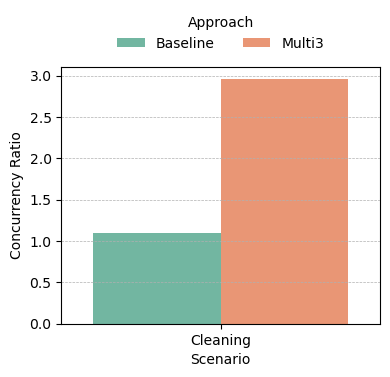

In [62]:
melted = concurrency_average_df.melt(id_vars='scenario', value_vars=['CR_baseline', 'CR_multi3'], var_name='mode', value_name='CR')

melted['mode'] = melted['mode'].replace({'CR_baseline': 'Baseline', 'CR_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='CR', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Concurrency Ratio')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/multi-mission/online-income/images/cr_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Wilcoxon test on paired differences

In [63]:
wilcoxon_test = wilcoxon(pivot_concurrency_df['CR_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test (on Concurrency Ratio):\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test (on Concurrency Ratio):
Statistic: 0.0, p-value: 1.4901161193847656e-08


In [64]:
median_workload_cv = pivot_concurrency_df['CR_paired_diff'].median()
percentile_5_workload_cv = pivot_concurrency_df['CR_paired_diff'].quantile(0.05)

print(f"Concurrency ratio paired difference median: {median_workload_cv}")
print(f"5th percentile: {percentile_5_workload_cv}")

Concurrency ratio paired difference median: 0.9604778453984095
5th percentile: 0.39042640769158277


## EQ5 Analyzing dynamic mission arrival

$TTFS_m =
        \min_{t \in T_m} \mathit{start}(t)
        -
        \mathit{arrival}(m),
 $


 $MRT_m =
        \max_{t \in T_m} \mathit{end}(t)
        -
        \mathit{arrival}(m)
$

In [65]:
results = []

for mission_id, mission_data in robot_execution_data.items():
    robots = mission_data["robots"]

    labels = mission_id.split("_")
    robot_count = int(labels[1])
    mission_size = int(labels[2])
    inv_id = int(labels[5][1])
    scenario = labels[4]
    mode = labels[6]

    dry_starts = []
    dry_ends = []
    main_starts = []
    main_ends = []

    for robot_name, robot_data in robots.items():
        for interval in robot_data.get("non_idle_intervals", []):
            if len(interval) < 3:
                continue

            start_ts, duration, task_name = interval
            task_name = str(task_name or "").strip()

            if not task_name:
                continue

            # The file stores each interval as [start_timestamp, duration, task_name].
            end_ts = float(start_ts) + float(duration)

            if task_name.lower() == "dry":
                dry_starts.append(float(start_ts))
                dry_ends.append(end_ts)
            else:
                main_starts.append(float(start_ts))
                main_ends.append(end_ts)

    ttfs_main = min(main_starts) if main_starts else np.nan
    ttfs_dry = min(dry_starts) - 30 if dry_starts else np.nan # Mission arrives after 30 seconds
    mrt_main = max(main_ends) if main_ends else np.nan
    mrt_dry = max(dry_ends) - 30 if dry_ends else np.nan # Mission arrives after 30 seconds

    results.append({
        "scenario": scenario,
        "robot_count": robot_count,
        "mission_size": mission_size,
        "inventory_id": inv_id,
        "mode": mode,
        "ttfs_main": ttfs_main,
        "ttfs_dry": ttfs_dry,
        "mrt_main": mrt_main,
        "mrt_dry": mrt_dry
    })

service_times_df = pd.DataFrame(results)
service_times_df

,scenario,robot_count,mission_size,inventory_id,mode,ttfs_main,ttfs_dry,mrt_main,mrt_dry
0,cleaning,5,20,0,bl2,6.022590,873.021345,1006.508599,894.034953
1,cleaning,10,20,0,multi3,4.509844,7.509167,130.506550,13.505936
2,cleaning,10,10,0,bl1,4.558622,1.513299,489.047070,19.505580
3,cleaning,5,10,1,bl2,4.509280,334.509882,462.033109,361.510277
4,cleaning,10,20,1,bl1,4.510006,1.509428,984.049014,19.507792
...,...,...,...,...,...,...,...,...,...
103,cleaning,10,2,0,bl1,4.509376,1.508902,76.510041,19.508818
104,cleaning,10,2,0,bl0,4.506654,1.510358,79.505140,19.509449
105,cleaning,2,10,2,bl1,6.013076,429.012679,475.506605,445.506605
106,cleaning,2,2,0,bl1,6.021837,69.020513,114.021618,87.010583


In [66]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_service_times_baseline = service_times_df[service_times_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_service_times_baseline_avg = (
    df_service_times_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "ttfs_main": "mean",
        "ttfs_dry": "mean",
        "mrt_main": "mean",
        "mrt_dry": "mean",
    })
)

df_service_times_baseline_avg["mode"] = "baseline"

df_service_times_multi3 = service_times_df[service_times_df["mode"] == "multi3"].copy()

df_service_times_grouped = pd.concat([df_service_times_baseline_avg, df_service_times_multi3], ignore_index=True)

df_service_times_grouped = df_service_times_grouped[group_cols + ["mode", "ttfs_main", "ttfs_dry", "mrt_main", "mrt_dry"]]
df_service_times_grouped

,scenario,robot_count,mission_size,inventory_id,mode,ttfs_main,ttfs_dry,mrt_main,mrt_dry
0,cleaning,2,2,0,baseline,5.517992,69.521424,112.516291,87.533474
1,cleaning,2,2,1,baseline,5.513929,76.512758,111.511321,96.512629
2,cleaning,2,2,2,baseline,6.022995,49.026333,88.019562,65.507971
3,cleaning,2,10,0,baseline,5.517392,351.518154,460.008407,369.511417
4,cleaning,2,10,1,baseline,6.017701,467.014447,516.018913,488.014288
5,cleaning,2,10,2,baseline,6.014438,437.018927,477.515518,453.512725
6,cleaning,2,20,0,baseline,6.021512,906.023751,963.013516,926.020227
7,cleaning,2,20,1,baseline,6.023444,790.022902,840.013026,807.516585
8,cleaning,2,20,2,baseline,6.024329,843.020111,888.516837,863.013374
9,cleaning,5,2,0,baseline,5.023643,16.528888,108.521685,38.525617


In [67]:
pivot_service_times_df = df_service_times_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["ttfs_main", "ttfs_dry", "mrt_main", "mrt_dry"]
)

pivot_service_times_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_service_times_df.columns]

pivot_service_times_df = pivot_service_times_df.reset_index()

pivot_service_times_df["ttfs_main_diff_percentage"] = (
    (pivot_service_times_df["ttfs_main_multi3"] - pivot_service_times_df["ttfs_main_baseline"])
    / pivot_service_times_df["ttfs_main_baseline"]
) * 100

pivot_service_times_df["ttfs_dry_diff_percentage"] = (
    (pivot_service_times_df["ttfs_dry_multi3"] - pivot_service_times_df["ttfs_dry_baseline"])
    / pivot_service_times_df["ttfs_dry_baseline"]
) * 100

pivot_service_times_df["ttfs_main_paired_diff"] = pivot_service_times_df["ttfs_main_baseline"] - pivot_service_times_df["ttfs_main_multi3"]
pivot_service_times_df["ttfs_dry_paired_diff"] = pivot_service_times_df["ttfs_dry_baseline"] - pivot_service_times_df["ttfs_dry_multi3"]

pivot_service_times_df["mrt_main_diff_percentage"] = (
    (pivot_service_times_df["mrt_main_multi3"] - pivot_service_times_df["mrt_main_baseline"])
    / pivot_service_times_df["mrt_main_baseline"]
) * 100

pivot_service_times_df["mrt_dry_diff_percentage"] = (
    (pivot_service_times_df["mrt_dry_multi3"] - pivot_service_times_df["mrt_dry_baseline"])
    / pivot_service_times_df["mrt_dry_baseline"]
) * 100

pivot_service_times_df["mrt_main_paired_diff"] = pivot_service_times_df["mrt_main_baseline"] - pivot_service_times_df["mrt_main_multi3"]
pivot_service_times_df["mrt_dry_paired_diff"] = pivot_service_times_df["mrt_dry_baseline"] - pivot_service_times_df["mrt_dry_multi3"]

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "ttfs_main_diff_percentage",
    "ttfs_dry_diff_percentage",
    "ttfs_main_paired_diff",
    "ttfs_dry_paired_diff",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
    "mrt_main_diff_percentage",
    "mrt_dry_diff_percentage",
    "mrt_main_paired_diff",
    "mrt_dry_paired_diff",
]

pivot_service_times_df = pivot_service_times_df[ordered_cols]

pivot_service_times_df

,scenario,robot_count,mission_size,inventory_id,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,ttfs_main_diff_percentage,ttfs_dry_diff_percentage,ttfs_main_paired_diff,ttfs_dry_paired_diff,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3,mrt_main_diff_percentage,mrt_dry_diff_percentage,mrt_main_paired_diff,mrt_dry_paired_diff
0,cleaning,2,2,0,5.517992,6.018938,69.521424,15.022830,9.078413,-78.391079,-0.500946,54.498594,112.516291,108.019715,87.533474,42.020247,-3.996378,-51.995225,4.496576,45.513227
1,cleaning,2,2,1,5.513929,6.014335,76.512758,21.023957,9.075320,-72.522285,-0.500407,55.488801,111.511321,112.508743,96.512629,42.016429,0.894458,-56.465357,-0.997422,54.496200
2,cleaning,2,2,2,6.022995,6.023001,49.026333,6.022293,0.000099,-87.716208,-0.000006,43.004040,88.019562,66.021577,65.507971,24.017785,-24.992155,-63.336089,21.997985,41.490187
3,cleaning,2,10,0,5.517392,6.013420,351.518154,6.016118,8.990270,-98.288533,-0.496028,345.502036,460.008407,324.021297,369.511417,30.022989,-29.561875,-91.874950,135.987109,339.488428
4,cleaning,2,10,1,6.017701,6.020323,467.014447,18.023952,0.043564,-96.140601,-0.002622,448.990495,516.018913,357.013544,488.014288,36.016009,-30.813865,-92.619886,159.005369,451.998279
5,cleaning,2,10,2,6.014438,6.021169,437.018927,6.020211,0.111911,-98.622437,-0.006731,430.998716,477.515518,315.020325,453.512725,24.021057,-34.029301,-94.703333,162.495193,429.491668
6,cleaning,2,20,0,6.021512,6.026545,906.023751,6.025737,0.083584,-99.334925,-0.005033,899.998014,963.013516,577.510306,926.020227,24.024985,-40.030924,-97.405566,385.503210,901.995243
7,cleaning,2,20,1,6.023444,6.028303,790.022902,12.024012,0.080680,-98.478017,-0.004860,777.998890,840.013026,576.021816,807.516585,30.015978,-31.427038,-96.282927,263.991210,777.500606
8,cleaning,2,20,2,6.024329,6.017519,843.020111,12.014668,-0.113041,-98.574806,0.006810,831.005442,888.516837,592.506083,863.013374,39.021967,-33.315154,-95.478405,296.010753,823.991407
9,cleaning,5,2,0,5.023643,4.508783,16.528888,1.504425,-10.248749,-90.898209,0.514861,15.024463,108.521685,79.509658,38.525617,19.508555,-26.733853,-49.362121,29.012027,19.017062


#### Computing averages per configuration

In [68]:
service_times_average_df = (
    pivot_service_times_df.groupby(["mission_size", "robot_count"])
    .agg({
        "ttfs_main_baseline": "mean",
        "ttfs_main_multi3": "mean",
        "ttfs_dry_baseline": "mean",
        "ttfs_dry_multi3": "mean",
        "mrt_main_baseline": "mean",
        "mrt_main_multi3": "mean",
        "mrt_dry_baseline": "mean",
        "mrt_dry_multi3": "mean",
    })
    .reset_index()
)

service_times_average_df.columns = [
    "mission_size",
    "robot_count",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
]

service_times_average_df

,mission_size,robot_count,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3
0,2,2,5.684972,6.018758,65.020172,14.023027,104.015724,95.516678,83.184691,36.018154
1,2,5,5.526726,4.509734,8.853816,1.507200,98.187983,66.528873,30.020882,22.508777
2,2,10,4.679111,4.508878,1.508440,1.508006,94.850686,58.023858,20.844390,26.508387
3,10,2,5.849844,6.018304,418.517176,10.020094,484.514279,332.018389,437.012810,30.020018
4,10,5,5.356917,4.511538,376.185746,10.520172,472.690221,151.521506,398.520921,28.525489
5,10,10,4.513344,4.508969,1.510108,5.506993,459.028293,85.047528,20.841755,26.505897
6,20,2,6.023095,6.024122,846.355588,10.021472,897.181126,582.012735,865.516729,31.020977
7,20,5,4.844257,5.020885,749.512528,5.512396,963.015358,327.019541,770.845455,26.021666
8,20,10,4.853701,4.508517,1.681855,10.510897,930.536017,138.509116,20.014231,19.509451


In [69]:
service_times_average_df = (
    pivot_service_times_df.groupby(["robot_count"])
    .agg({
        "ttfs_main_baseline": "mean",
        "ttfs_main_multi3": "mean",
        "ttfs_dry_baseline": "mean",
        "ttfs_dry_multi3": "mean",
        "mrt_main_baseline": "mean",
        "mrt_main_multi3": "mean",
        "mrt_dry_baseline": "mean",
        "mrt_dry_multi3": "mean",
    })
    .reset_index()
)

service_times_average_df.columns = [
    "robot_count",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
]

service_times_average_df

,robot_count,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3
0,2,5.852637,6.020395,443.297645,11.354864,495.237043,336.515934,461.904743,32.353050
1,5,5.242633,4.680719,378.184030,5.846589,511.297854,181.689973,399.795753,25.685311
2,10,4.682052,4.508788,1.566801,5.841965,494.804999,93.860167,20.566792,24.174578


In [70]:
service_times_average_df = (
    pivot_service_times_df.groupby(["mission_size"])
    .agg({
        "ttfs_main_baseline": "mean",
        "ttfs_main_multi3": "mean",
        "ttfs_dry_baseline": "mean",
        "ttfs_dry_multi3": "mean",
        "mrt_main_baseline": "mean",
        "mrt_main_multi3": "mean",
        "mrt_dry_baseline": "mean",
        "mrt_dry_multi3": "mean",
    })
    .reset_index()
)

service_times_average_df.columns = [
    "mission_size",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
]

service_times_average_df

,mission_size,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3
0,2,5.296936,5.012457,25.127476,5.679411,99.018131,73.356470,44.683321,28.345106
1,10,5.240035,5.012937,265.404343,8.682420,472.077598,189.529141,285.458495,28.350468
2,20,5.240351,5.184508,532.516657,8.681588,930.244167,349.180464,552.125471,25.517365


In [71]:
service_times_average_df = (
    pivot_service_times_df.groupby(["scenario"])
    .agg({
        "ttfs_main_baseline": "mean",
        "ttfs_main_multi3": "mean",
        "ttfs_dry_baseline": "mean",
        "ttfs_dry_multi3": "mean",
        "mrt_main_baseline": "mean",
        "mrt_main_multi3": "mean",
        "mrt_dry_baseline": "mean",
        "mrt_dry_multi3": "mean",
    })
    .reset_index()
)

service_times_average_df.columns = [
    "scenario",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
]

melted = (
    service_times_average_df.melt(
        id_vars="scenario",
        value_vars=[
            "ttfs_main_baseline",
            "ttfs_main_multi3",
            "ttfs_dry_baseline",
            "ttfs_dry_multi3",
            "mrt_main_baseline",
            "mrt_main_multi3",
            "mrt_dry_baseline",
            "mrt_dry_multi3",
        ],
        var_name="metric_mode",
        value_name="value",
    )
)

melted[["metric", "mode"]] = melted["metric_mode"].str.rsplit("_", n=1, expand=True)
melted["mode"] = melted["mode"].replace({"baseline": "Baseline", "multi3": "Multi3"})
melted["metric"] = melted["metric"].replace({
    "ttfs_main": "TTFS Main",
    "ttfs_dry": "TTFS Dry",
    "mrt_main": "MRT Main",
    "mrt_dry": "MRT Dry",
})
melted["scenario"] = melted["scenario"].str.capitalize()

service_times_average_df

,scenario,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3
0,cleaning,5.259107,5.069967,274.349492,7.68114,500.446632,204.022025,294.089096,27.404313


#### Wilcoxon test on paired differences

In [72]:
for metric in ['ttfs_main', 'ttfs_dry', 'mrt_main', 'mrt_dry']:
    paired_diff = pivot_service_times_df[f'{metric}_paired_diff']
    wilcoxon_test = wilcoxon(paired_diff, alternative='two-sided')
    print(f"Wilcoxon signed-rank test on {metric}:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}\n")

Wilcoxon signed-rank test on ttfs_main:
Statistic: 124.0, p-value: 0.12253367900848389

Wilcoxon signed-rank test on ttfs_dry:
Statistic: 44.0, p-value: 0.00020888447761535645

Wilcoxon signed-rank test on mrt_main:
Statistic: 1.0, p-value: 2.9802322387695312e-08

Wilcoxon signed-rank test on mrt_dry:
Statistic: 49.0, p-value: 0.00038070976734161377

